# Библиотеки и базовые настройки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.ensemble import IsolationForest
from itertools import permutations
from itertools import combinations

In [2]:
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [3]:
np.random.seed(42)

# Загрузка данных и просмотр

- Загружаем данные из текстового файла. Каждая строка — это один сигнал с детектора, состоящий из 500 точек оцифровки.
Первые 4 колонки и 504-я удаляются — это служебная информация (идентификаторы, метаданные).

In [4]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [5]:
print("Размер датасета :", dataset.shape)

Размер датасета : (23479, 500)


Text(0, 0.5, 'bit ADC')

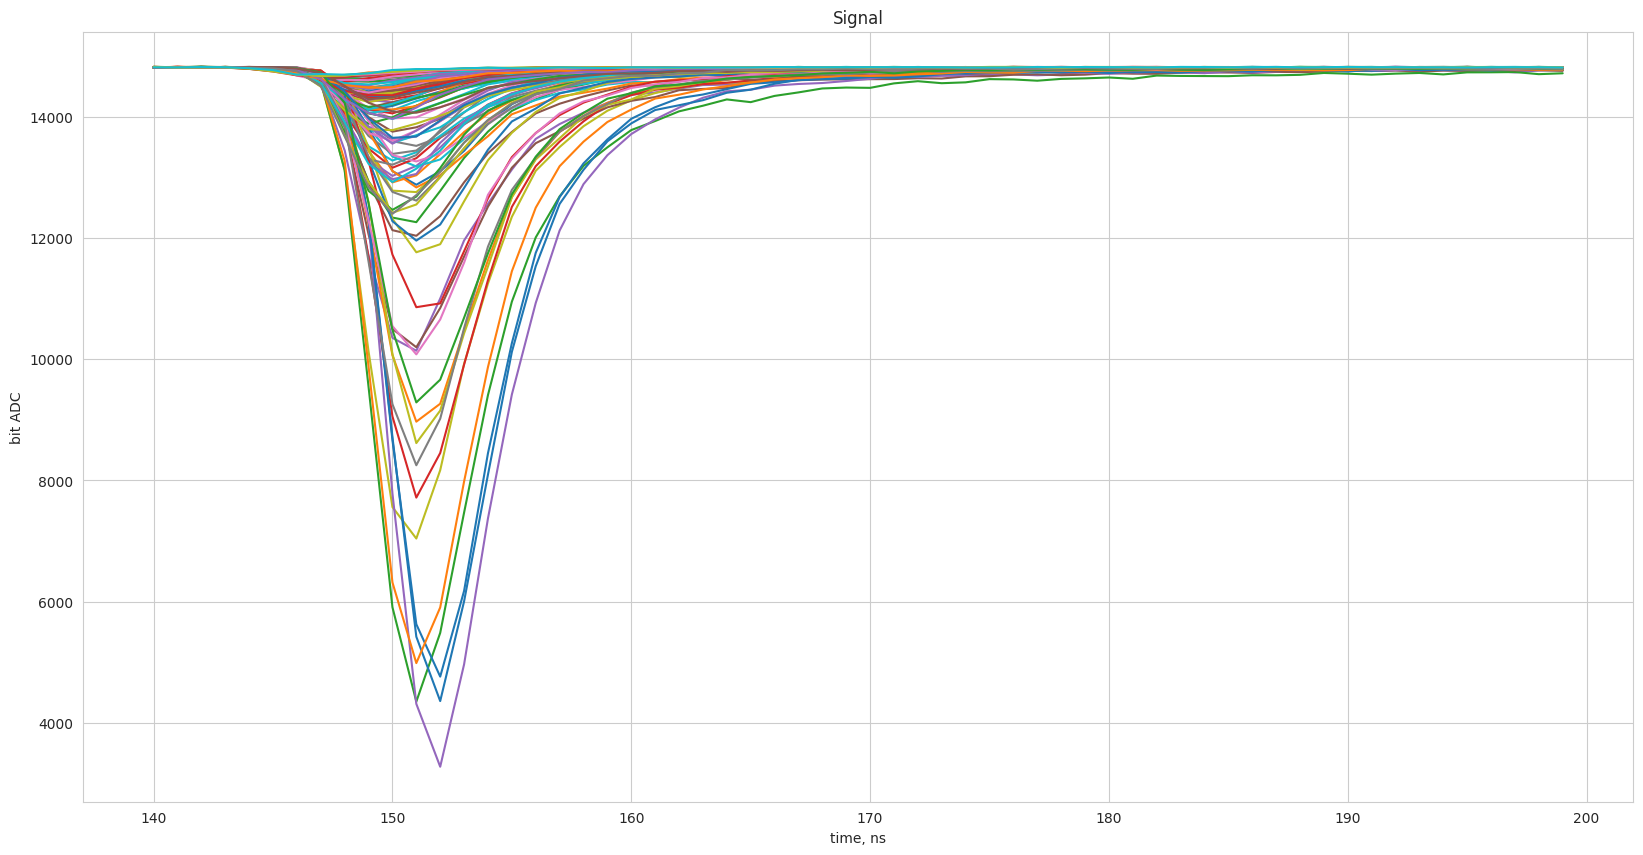

In [6]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

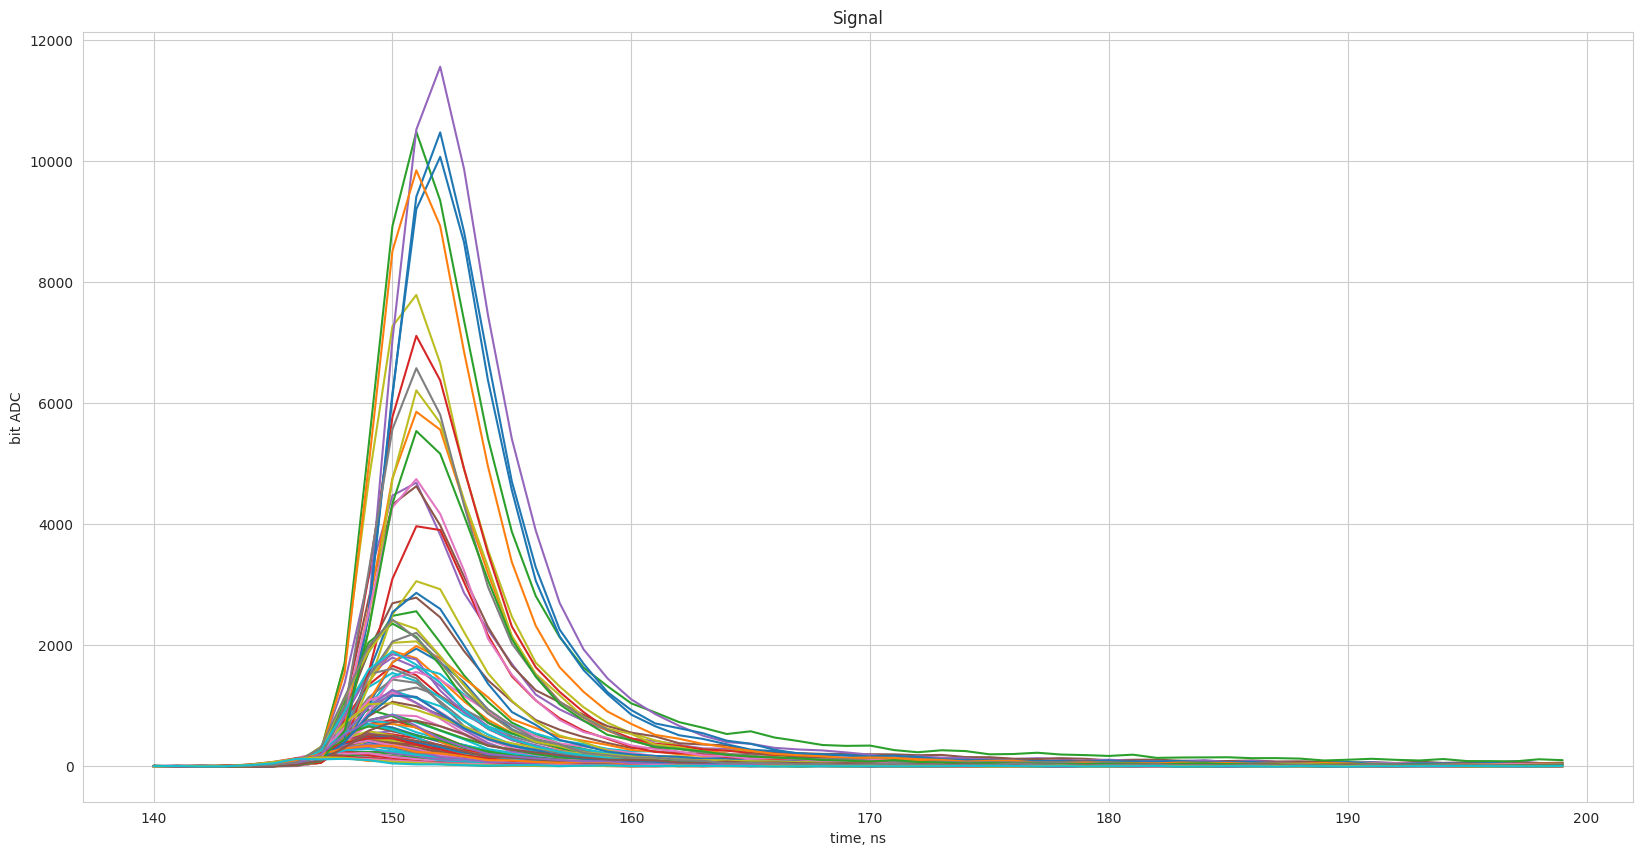

In [7]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


In [8]:
print("Первые 5 строк:")
print(dataset.head())

Первые 5 строк:
     0      1      2      3      4      5      6      7      8      9    ...  \
0  14820  14823  14824  14822  14818  14820  14824  14822  14820  14820  ...   
1  14820  14822  14820  14826  14824  14822  14820  14822  14823  14821  ...   
2  14820  14820  14822  14825  14820  14824  14824  14819  14823  14824  ...   
3  14828  14822  14818  14824  14824  14822  14820  14822  14824  14820  ...   
4  14823  14815  14823  14821  14827  14820  14823  14824  14816  14821  ...   

     490    491    492    493    494    495    496    497    498    499  
0  14828  14822  14815  14815  14817  14819  14820  14822  14820  14819  
1  14828  14817  14824  14822  14824  14819  14820  14819  14822  14820  
2  14820  14821  14820  14820  14818  14821  14823  14820  14820  14821  
3  14824  14826  14822  14821  14820  14828  14820  14822  14823  14822  
4  14820  14820  14823  14828  14824  14820  14824  14824  14822  14825  

[5 rows x 500 columns]


In [9]:
print("Названия столбцов:", dataset.columns.tolist()[:10], "...", dataset.columns.tolist()[-5:])

Названия столбцов: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [495, 496, 497, 498, 499]


In [10]:
print("Тип данных:", dataset.dtypes.value_counts())

Тип данных: int64    500
Name: count, dtype: int64


In [11]:
print("Всего пропусков:", dataset.isnull().sum().sum())

Всего пропусков: 0


In [12]:
print("Описательная статистика:", dataset.describe().round(1))

Описательная статистика:            0        1        2        3        4        5        6        7    \
count  23479.0  23479.0  23479.0  23479.0  23479.0  23479.0  23479.0  23479.0   
mean   14823.0  14823.0  14823.0  14823.0  14823.0  14823.0  14823.0  14823.0   
std        2.8      2.8      2.8      2.9      2.8      2.8      2.8      2.8   
min    14812.0  14812.0  14812.0  14811.0  14812.0  14812.0  14812.0  14811.0   
25%    14821.0  14821.0  14821.0  14821.0  14821.0  14821.0  14821.0  14821.0   
50%    14823.0  14823.0  14823.0  14823.0  14823.0  14823.0  14823.0  14823.0   
75%    14824.0  14824.0  14825.0  14825.0  14825.0  14824.0  14824.0  14824.0   
max    14834.0  14835.0  14834.0  14835.0  14834.0  14835.0  14835.0  14833.0   

           8        9    ...      490      491      492      493      494  \
count  23479.0  23479.0  ...  23479.0  23479.0  23479.0  23479.0  23479.0   
mean   14823.0  14823.0  ...  14822.3  14822.3  14822.3  14822.2  14822.3   
std        2.8

Итог :
- Данные состоят из 23 479 сигналов по 500 временных точек каждый.
- Пропусков нет, значения находятся в узком диапазоне (~14 200–14 830) — это ADC-коды.
- Различия между сигналами скрыты в форме импульса, а не в абсолютных значениях.

# Визуализация сырых сигналов

Смотрим на сырые сигналы и их физически правильное представление (инверсия).
В сцинтилляционных детекторах сигнал регистрируется в отрицательной логике, поэтому для анализа его "переворачивают":
инвертированный сигнал = 2^14 - ADC - 1560.

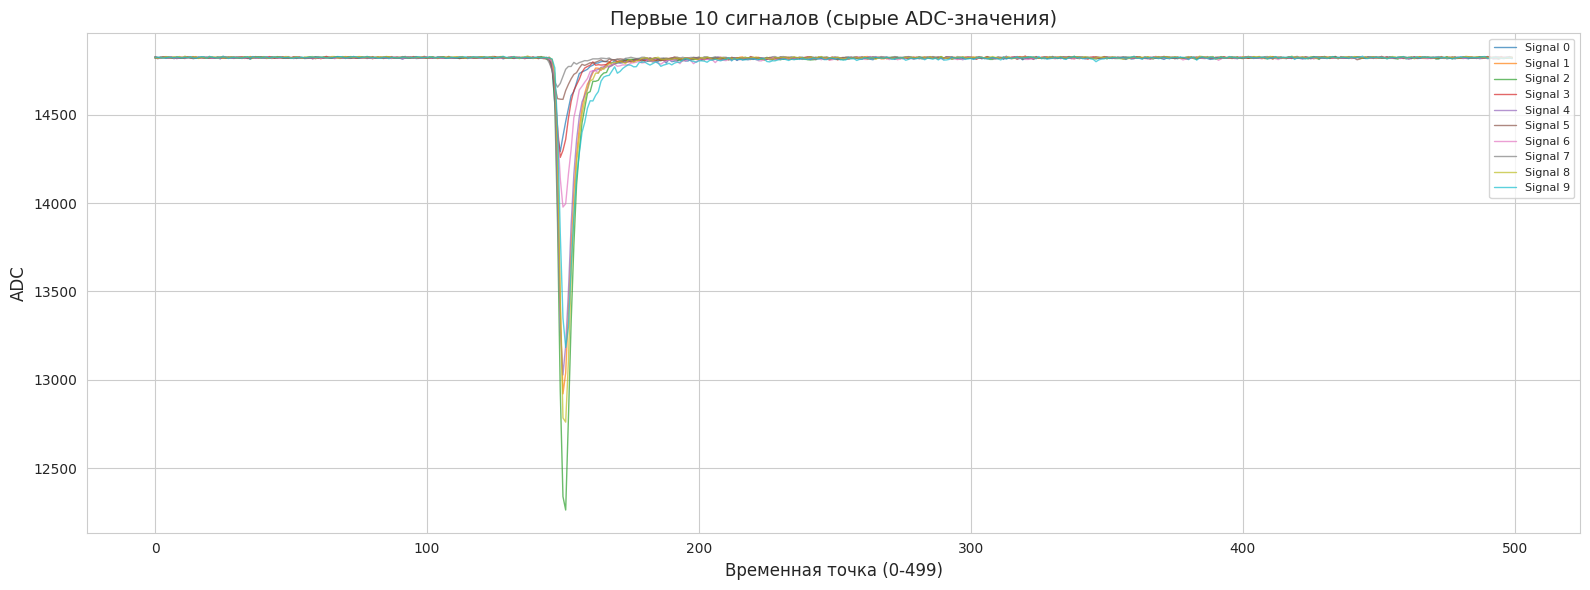

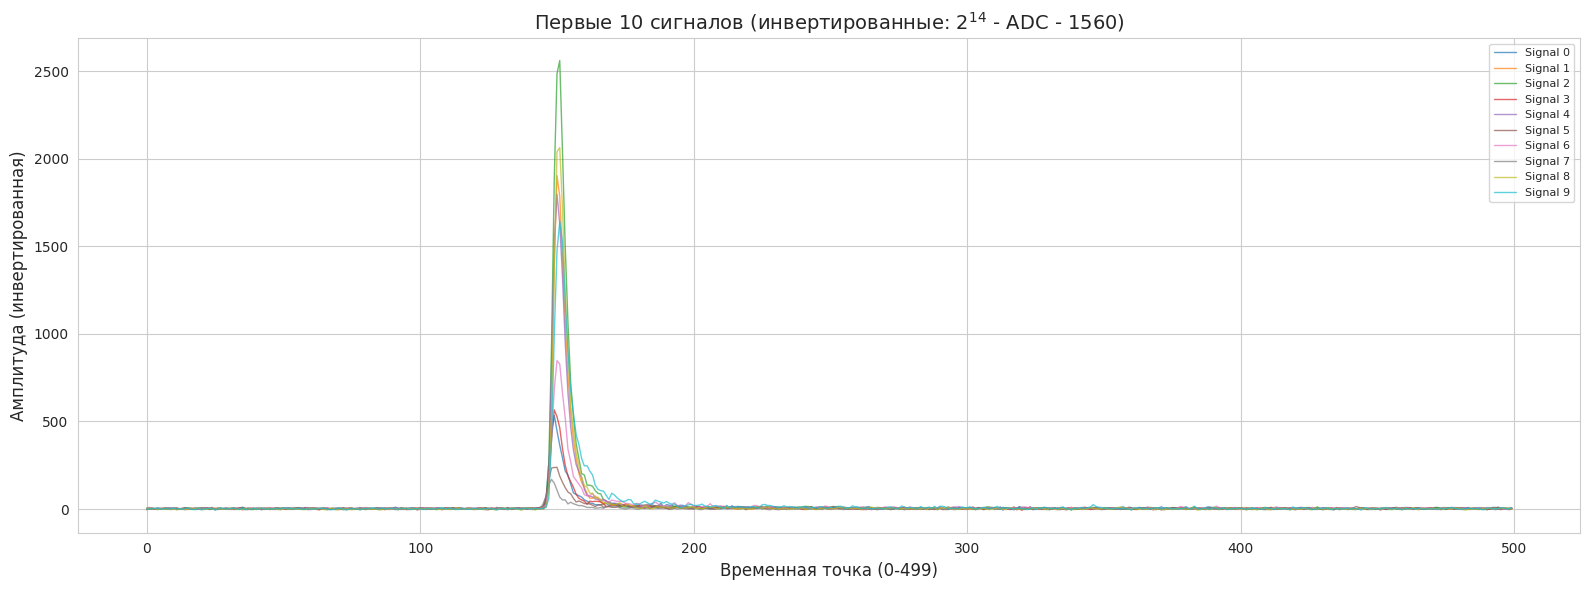

In [13]:
# Визуализация первых 10 сигналов — сырые данные
N_signals = 10
plt.figure(figsize=(16, 6))
for i in range(N_signals):
    plt.plot(dataset.iloc[i].values, alpha=0.7, linewidth=1, label=f'Signal {i}')
plt.title('Первые 10 сигналов (сырые ADC-значения)', fontsize=14)
plt.xlabel('Временная точка (0-499)', fontsize=12)
plt.ylabel('ADC', fontsize=12)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# Теперь с инверсией — как в примере (физически правильное отображение импульса)
plt.figure(figsize=(16, 6))
for i in range(N_signals):
    inverted = 2**14 - dataset.iloc[i].values - 1560
    plt.plot(inverted, alpha=0.7, linewidth=1, label=f'Signal {i}')
plt.title('Первые 10 сигналов (инвертированные: $2^{14}$ - ADC - 1560)', fontsize=14)
plt.xlabel('Временная точка (0-499)', fontsize=12)
plt.ylabel('Амплитуда (инвертированная)', fontsize=12)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Итог :

- На графиках видна характерная форма сцинтилляционного импульса:
   - Базовый уровень (первые +- 150 отсчётов)
   - Резкий фронт (нарастание) — частица попадает в детектор
   - Плавный спад (хвост) — высвечивание сцинтиллятора

Сигналы похожи по амплитуде, но отличаются формой спада — именно здесь кроется различие между гамма-квантами и нейтронами.

Тперь рассматриваем 50 случайных сигналов, чтобы оценить общую картину и разброс форм:

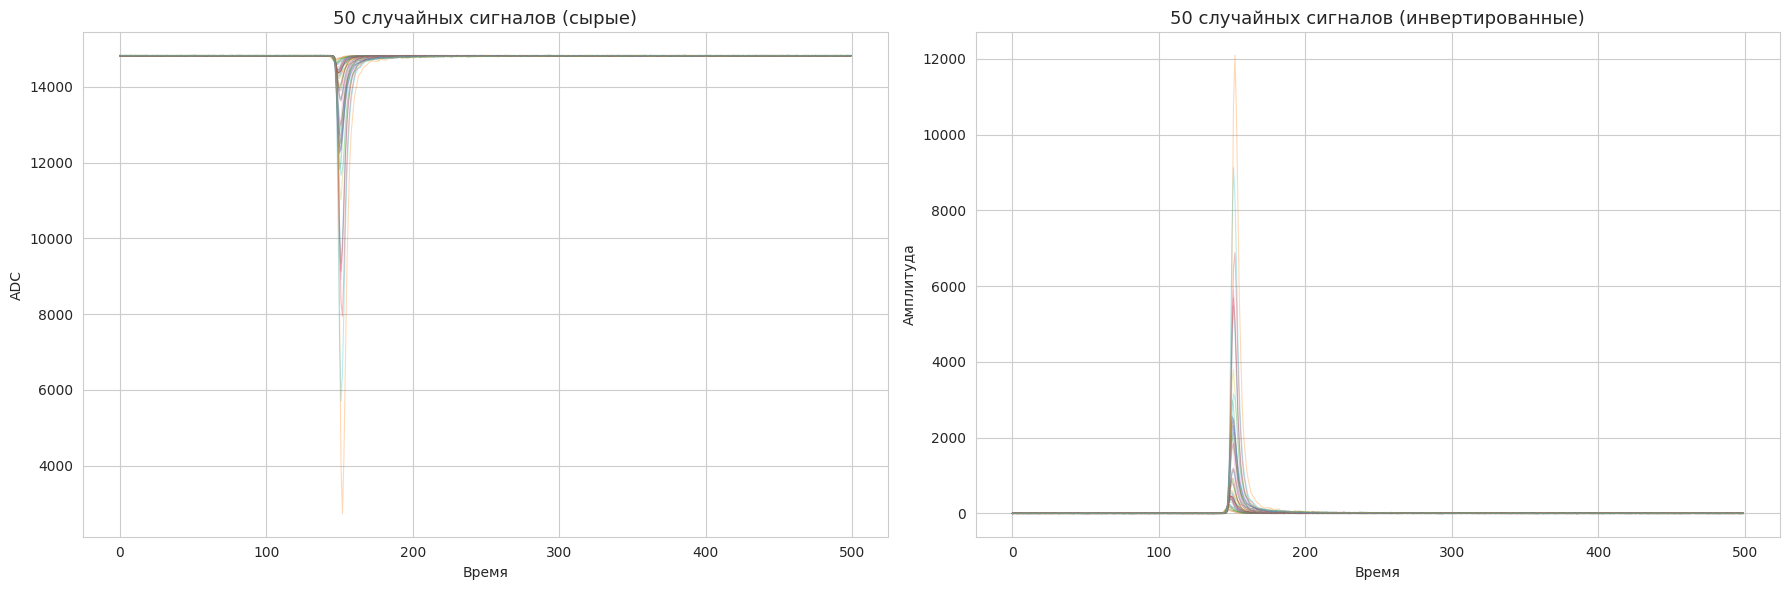

In [14]:
random_idx = np.random.choice(len(dataset), 50, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Сырые
for idx in random_idx:
    axes[0].plot(dataset.iloc[idx].values, alpha=0.3, linewidth=0.8)
axes[0].set_title('50 случайных сигналов (сырые)', fontsize=13)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('ADC')

# Инвертированные
for idx in random_idx:
    inverted = 2**14 - dataset.iloc[idx].values - 1560
    axes[1].plot(inverted, alpha=0.3, linewidth=0.8)
axes[1].set_title('50 случайных сигналов (инвертированные)', fontsize=13)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Амплитуда')

plt.tight_layout()
plt.show()

Итог :
- Видно, что основная вариативность — в амплитуде пика и длительности хвоста (спада).

Строим усреднённый сигнал по всем 23 479 записям с коридором стандартного отклонения.
Это поможет понять, в каких участках сигнала наибольший разброс.

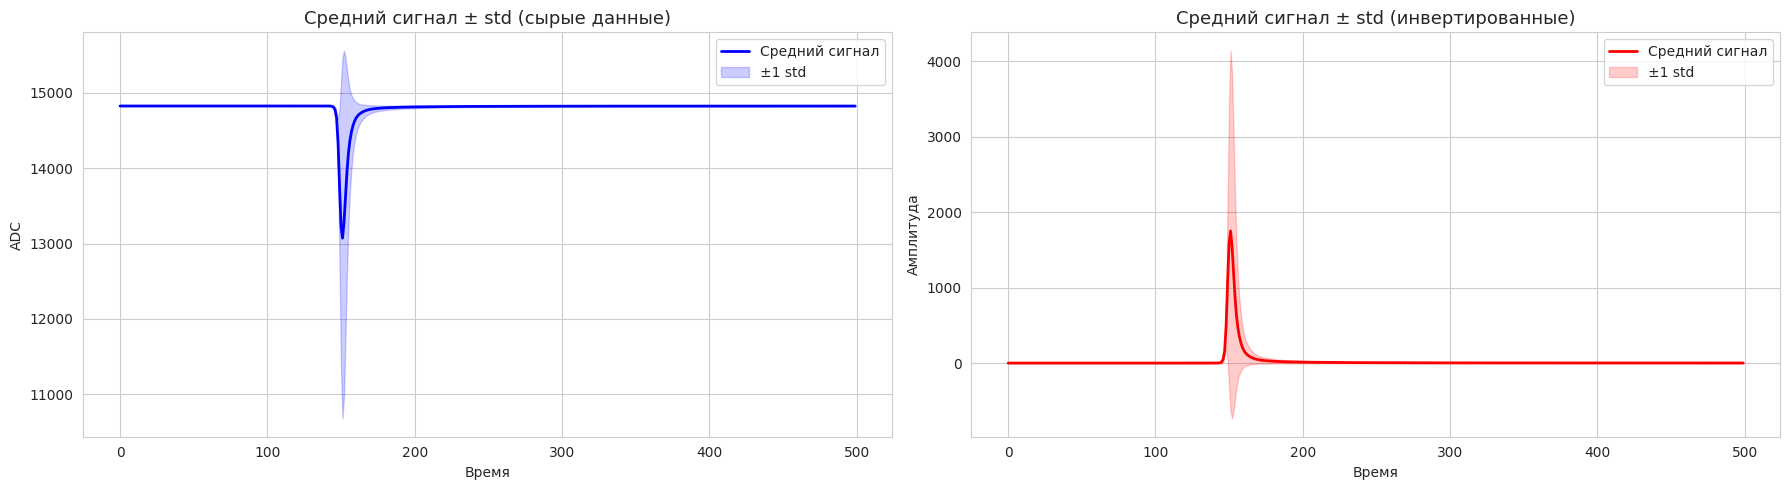

In [15]:
mean_signal = dataset.mean(axis=0)
std_signal = dataset.std(axis=0)

# Инвертированные
mean_inv = 2**14 - mean_signal - 1560
std_inv = std_signal  # std не меняется от линейного преобразования

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Сырой средний
axes[0].plot(mean_signal, color='blue', linewidth=2, label='Средний сигнал')
axes[0].fill_between(range(500), mean_signal - std_signal, mean_signal + std_signal,
                      alpha=0.2, color='blue', label='±1 std')
axes[0].set_title('Средний сигнал ± std (сырые данные)', fontsize=13)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('ADC')
axes[0].legend()

# Инвертированный средний
axes[1].plot(mean_inv, color='red', linewidth=2, label='Средний сигнал')
axes[1].fill_between(range(500), mean_inv - std_inv, mean_inv + std_inv,
                      alpha=0.2, color='red', label='±1 std')
axes[1].set_title('Средний сигнал ± std (инвертированные)', fontsize=13)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
print(f"Средняя амплитуда сигнала (сырая): {mean_signal.mean():.1f} +- {std_signal.mean():.1f}")
print(f"Максимальное отклонение от среднего по всем точкам: {dataset.max().max() - dataset.min().min()}")

Средняя амплитуда сигнала (сырая): 14796.7 +- 36.1
Максимальное отклонение от среднего по всем точкам: 14838


Итог:
- Наибольший разброс (std) наблюдается в области пика и начала спада —
именно здесь сигналы сильнее всего отличаются друг от друга.
- Область базового уровня и дальнего хвоста более стабильны.
- Средняя амплитуда: ~14797, максимальное отклонение от среднего: ~14838.

# Feature Engineering v1 (13 признаков)

Извлекаем из каждого сигнала 13 статистических признаков, которые описывают его форму -- это поможет перейти от 500-мерного временного ряда к компактному набору характеристик.

Признаки:
- baseline — базовый уровень сигнала
- peak_amplitude — амплитуда пика
- peak_position — положение пика во времени
- rise_time — время нарастания (10% → 90% амплитуды)
- fall_time — время спада (90% → 10% амплитуды)
- width_50 — ширина на полувысоте
- total_integral — полный интеграл сигнала
- integral_peak — интеграл в окрестности пика
- skewness — асимметрия распределения
- kurtosis — эксцесс (пикообразность)
- rise_fall_ratio — отношение времени нарастания ко времени спада
- peak_to_integral — отношение пика к интегралу
- asymmetry — асимметрия относительно пика

In [17]:
def extract_features(signal):
    """
    Извлечение признаков из одного сигнала (500 точек).
    signal: pd.Series или np.array сырых ADC-значений
    """
    # Инвертируем сигнал для физически правильного представления
    s = 2**14 - np.array(signal) - 1560

    features = {}

    features['baseline'] = np.mean(s[:50])
    features['peak_amplitude'] = np.max(s) - features['baseline']

    peak_idx = np.argmax(s)
    features['peak_position'] = peak_idx

    # Время нарастания (10% -> 90% амплитуды)
    threshold_10 = features['baseline'] + 0.1 * features['peak_amplitude']
    threshold_90 = features['baseline'] + 0.9 * features['peak_amplitude']

    rise_start = np.where(s[:peak_idx] >= threshold_10)[0]
    rise_end = np.where(s[:peak_idx] >= threshold_90)[0]
    features['rise_time'] = (rise_end[0] - rise_start[0]) if len(rise_start) > 0 and len(rise_end) > 0 else 0

    # Время спада (90% -> 10% после пика)
    fall_start = np.where(s[peak_idx:] <= threshold_90)[0]
    fall_end = np.where(s[peak_idx:] <= threshold_10)[0]
    features['fall_time'] = (fall_end[0] - fall_start[0]) if len(fall_start) > 0 and len(fall_end) > 0 else 0

    features['width_50'] = np.sum(s > (features['baseline'] + 0.5 * features['peak_amplitude']))

    features['total_integral'] = np.sum(s - features['baseline'])
    features['integral_peak'] = np.sum(s[max(0, peak_idx-10):min(500, peak_idx+10)] - features['baseline'])

    features['skewness'] = stats.skew(s)
    features['kurtosis'] = stats.kurtosis(s)

    features['rise_fall_ratio'] = features['rise_time'] / (features['fall_time'] + 1)
    features['peak_to_integral'] = features['peak_amplitude'] / (features['total_integral'] + 1)

    features['asymmetry'] = np.sum(s[:peak_idx]) / (np.sum(s[peak_idx:]) + 1)

    return features

features_list = []
for i in range(len(dataset)):
    features_list.append(extract_features(dataset.iloc[i]))

df_features = pd.DataFrame(features_list)
print(f"Извлечено признаков: {df_features.shape[1]}")
print(f"Количество сигналов: {df_features.shape[0]}")

Извлечено признаков: 13
Количество сигналов: 23479


In [18]:
print("Первые 5 строк признаков:", df_features.head().round(3))

Первые 5 строк признаков:    baseline  peak_amplitude  peak_position  rise_time  fall_time  width_50  \
0      2.52          530.48            149          0         10         5   
1      1.52         1901.48            150          0          7         5   
2      2.10         2557.90            151          3          7         5   
3      1.44          564.56            149          0          8         5   
4      2.40         1793.60            150          0          7         5   

   total_integral  integral_peak  skewness  kurtosis  rise_fall_ratio  \
0          4789.0         3195.6     8.209    73.233            0.000   
1         12353.0        10740.6     8.937    84.934            0.000   
2         16945.0        15076.0     8.870    83.455            0.375   
3          4558.0         3390.2     8.412    76.387            0.000   
4         11691.0        10363.0     8.863    83.049            0.000   

   peak_to_integral  asymmetry  
0             0.111      0.254  


In [19]:

print("Статистика признаков:", df_features.describe().round(3))

Статистика признаков:         baseline  peak_amplitude  peak_position  rise_time  fall_time  \
count  23479.000       23479.000      23479.000  23479.000  23479.000   
mean       1.033        1835.105        149.629      0.775      8.675   
std        0.856        2389.301          2.490      1.045      2.134   
min       -2.480         104.300        145.000      0.000      3.000   
25%        0.460         308.160        149.000      0.000      7.000   
50%        1.040         812.540        150.000      0.000      8.000   
75%        1.620        2315.050        151.000      2.000     10.000   
max        5.080       14824.840        472.000      4.000     21.000   

        width_50  total_integral  integral_peak   skewness   kurtosis  \
count  23479.000       23479.000       23479.00  23479.000  23479.000   
mean       5.224       13141.392       10837.64      8.422     76.999   
std        0.699       16097.185       13865.58      0.591      9.725   
min        3.000         213

In [20]:
print("Пропуски в признаках:", df_features.isnull().sum().sum())
print("Бесконечных значений:", np.sum(np.isinf(df_features.values)))

Пропуски в признаках: 0
Бесконечных значений: 0


Итог:
- Извлечено 13 признаков. Пропусков и бесконечностей нет.
- Признаки имеют сильно разный масштаб (peak_amplitude: 104–14825, baseline: -2.5–5.1),
поэтому перед кластеризацией потребуется стандартизация.
- Интересно: у 50% сигналов rise_time = 0 (фронт короче одного временного шага),
а fall_time варьируется от 3 до 21 — именно спад несёт больше всего информации (!)

#  Анализ корреляций v1

Строим матрицу корреляций признаков:
-  Сильно скоррелированные признаки несут дублирующую информацию,
и их можно удалить — это упростит модель без потери качества.

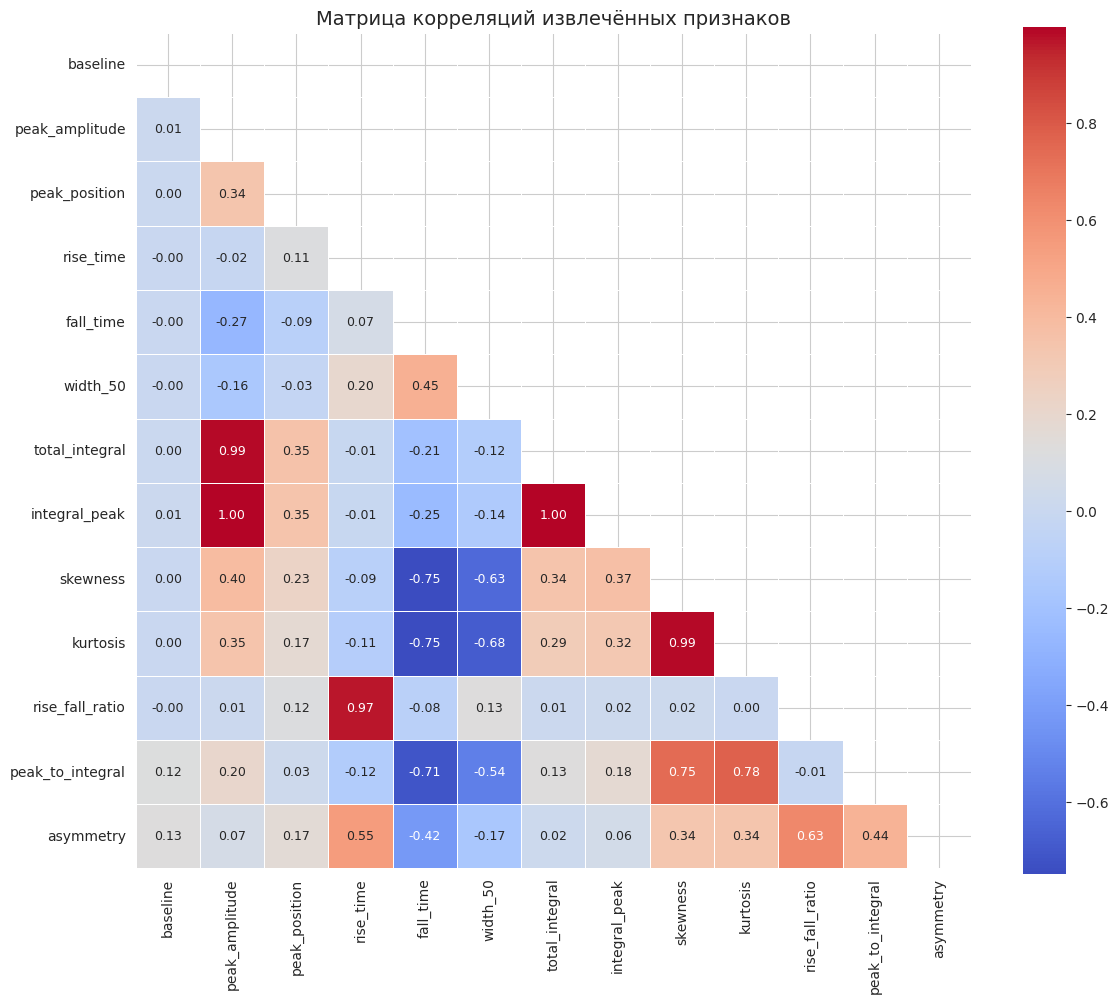

In [21]:
plt.figure(figsize=(12, 10))
corr_matrix = df_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={"size": 9})
plt.title('Матрица корреляций извлечённых признаков', fontsize=14)
plt.tight_layout()
plt.show()

Более детальный и текстовый разбор:

In [22]:
corr_matrix = df_features.corr()

# Находим все пары с |r| > 0.8 (кроме диагонали)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': round(corr_val, 4)
            })

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x['Корреляция']), reverse=True)

print(f"Найдено пар с |r| > 0.8: {len(high_corr_pairs)}\n")
for pair in high_corr_pairs:
    print(f"  {pair['Признак 1']:20s} <-> {pair['Признак 2']:20s} : {pair['Корреляция']:+.4f}")

Найдено пар с |r| > 0.8: 5

  peak_amplitude       <-> integral_peak        : +0.9985
  total_integral       <-> integral_peak        : +0.9956
  peak_amplitude       <-> total_integral       : +0.9903
  skewness             <-> kurtosis             : +0.9870
  rise_time            <-> rise_fall_ratio      : +0.9661


Найдено 5 пар с экстремально высокой корреляцией (>0.96).

Эти признаки дублируют друг друга --> надо удалить integral_peak, total_integral,
kurtosis, rise_fall_ratio — оставитьпо одному представителю из каждой группы.

In [23]:
print("Топ-3 корреляции для каждого признака (без самокорреляции):\n")
for col in corr_matrix.columns:
    top3 = corr_matrix[col].drop(col).abs().sort_values(ascending=False).head(3)
    print(f"  {col}:")
    for other, val in top3.items():
        actual_corr = corr_matrix.loc[col, other]
        print(f"      -> {other:20s} : {actual_corr:+.4f}")
    print()

Топ-3 корреляции для каждого признака (без самокорреляции):

  baseline:
      -> asymmetry            : +0.1276
      -> peak_to_integral     : +0.1236
      -> integral_peak        : +0.0099

  peak_amplitude:
      -> integral_peak        : +0.9985
      -> total_integral       : +0.9903
      -> skewness             : +0.3957

  peak_position:
      -> total_integral       : +0.3531
      -> integral_peak        : +0.3456
      -> peak_amplitude       : +0.3419

  rise_time:
      -> rise_fall_ratio      : +0.9661
      -> asymmetry            : +0.5536
      -> width_50             : +0.1988

  fall_time:
      -> kurtosis             : -0.7480
      -> skewness             : -0.7477
      -> peak_to_integral     : -0.7134

  width_50:
      -> kurtosis             : -0.6818
      -> skewness             : -0.6285
      -> peak_to_integral     : -0.5382

  total_integral:
      -> integral_peak        : +0.9956
      -> peak_amplitude       : +0.9903
      -> peak_position        

# PCA

Применяем метод главных компонент к отобранным 9 признакам после стандартизации.

Цель понять:
- сколько измерений действительно нужно для описания данных,
- какие исходные признаки вносят наибольший вклад в различия между сигналами.

- некореллированные признаки

In [24]:
selected_features = [
    'baseline',
    'peak_amplitude',
    'peak_position',
    'rise_time',
    'fall_time',
    'width_50',
    'skewness',
    'peak_to_integral',
    'asymmetry'
]

X_selected = df_features[selected_features].copy()
print(f"Отобрано признаков: {X_selected.shape[1]}")
print(f"Признаки: {list(X_selected.columns)}")

Отобрано признаков: 9
Признаки: ['baseline', 'peak_amplitude', 'peak_position', 'rise_time', 'fall_time', 'width_50', 'skewness', 'peak_to_integral', 'asymmetry']


- стандартизация

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
print(f"После стандартизации: mean ≈ {X_scaled.mean():.1f}, std ≈ {X_scaled.std():.1f}")

После стандартизации: mean ≈ -0.0, std ≈ 1.0


- PCA — смотрим объяснённую дисперсию

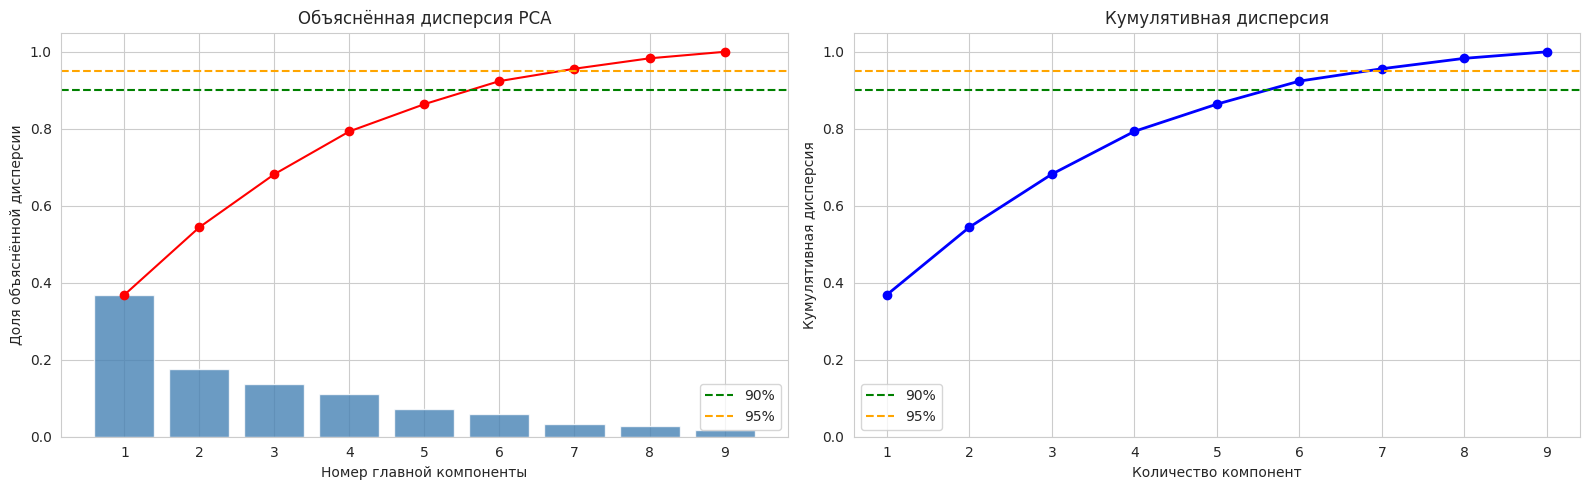

In [26]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, 10), pca.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].plot(range(1, 10), np.cumsum(pca.explained_variance_ratio_), 'ro-', markersize=6)
axes[0].axhline(y=0.9, color='green', linestyle='--', label='90%')
axes[0].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Доля объяснённой дисперсии')
axes[0].set_title('Объяснённая дисперсия PCA')
axes[0].legend()
axes[0].set_xticks(range(1, 10))

axes[1].plot(range(1, 10), np.cumsum(pca.explained_variance_ratio_), 'b-o', linewidth=2, markersize=6)
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Кумулятивная дисперсия')
axes[1].set_title('Кумулятивная дисперсия')
axes[1].legend()
axes[1].set_xticks(range(1, 10))
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [27]:
for i in range(9):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.3f} ({pca.explained_variance_ratio_[i]*100:.1f}%), кумулятивно: {np.cumsum(pca.explained_variance_ratio_)[i]*100:.1f}%")

n_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1
n_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Для 90% дисперсии нужно: {n_90} компонент")
print(f"Для 95% дисперсии нужно: {n_95} компонент")

PC1: 0.369 (36.9%), кумулятивно: 36.9%
PC2: 0.176 (17.6%), кумулятивно: 54.4%
PC3: 0.138 (13.8%), кумулятивно: 68.2%
PC4: 0.111 (11.1%), кумулятивно: 79.3%
PC5: 0.071 (7.1%), кумулятивно: 86.4%
PC6: 0.060 (6.0%), кумулятивно: 92.4%
PC7: 0.032 (3.2%), кумулятивно: 95.6%
PC8: 0.027 (2.7%), кумулятивно: 98.3%
PC9: 0.017 (1.7%), кумулятивно: 100.0%
Для 90% дисперсии нужно: 6 компонент
Для 95% дисперсии нужно: 7 компонент


- матрица нагрузок

In [28]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=selected_features
)
print("\nМатрица нагрузок (первые 3 компоненты):")
print(loadings.round(3))


Матрица нагрузок (первые 3 компоненты):
                    PC1    PC2    PC3
baseline          0.044  0.108 -0.205
peak_amplitude    0.235  0.020  0.619
peak_position     0.132  0.257  0.659
rise_time        -0.016  0.717 -0.088
fall_time        -0.468  0.036  0.100
width_50         -0.378  0.261  0.105
skewness          0.502 -0.092  0.071
peak_to_integral  0.475 -0.077 -0.220
asymmetry         0.292  0.569 -0.242


Итог:
- Для 90% дисперсии нужно 6 компонент из 9 — данные не сводятся к 2–3 измерениям, структура многомерная.
- PC1 (36.9%): форма хвоста (skewness, peak_to_integral, fall_time, width_50) — различие быстрых и медленных сигналов.
- PC2 (17.6%): крутизна фронта (rise_time, asymmetry).
- PC3 (13.8%): энергия и положение пика (peak_position, peak_amplitude).

Физически это соответствует трём основным характеристикам импульса:
хвост (тип частицы), фронт (условия регистрации), энергия (амплитуда сигнала).

# t-SNE и UMAP

- Эти нелинейные методы снижения размерности показывают, есть ли в данных естественные сгустки (кластеры), даже если они не видны в PCA.

- Из-за вычислительной сложности визуализацию делаем на подвыборке из 5000 случайных сигналов.

In [29]:
sample_idx = np.random.choice(len(X_scaled), 5000, replace=False)
X_sample = X_scaled[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X_sample)

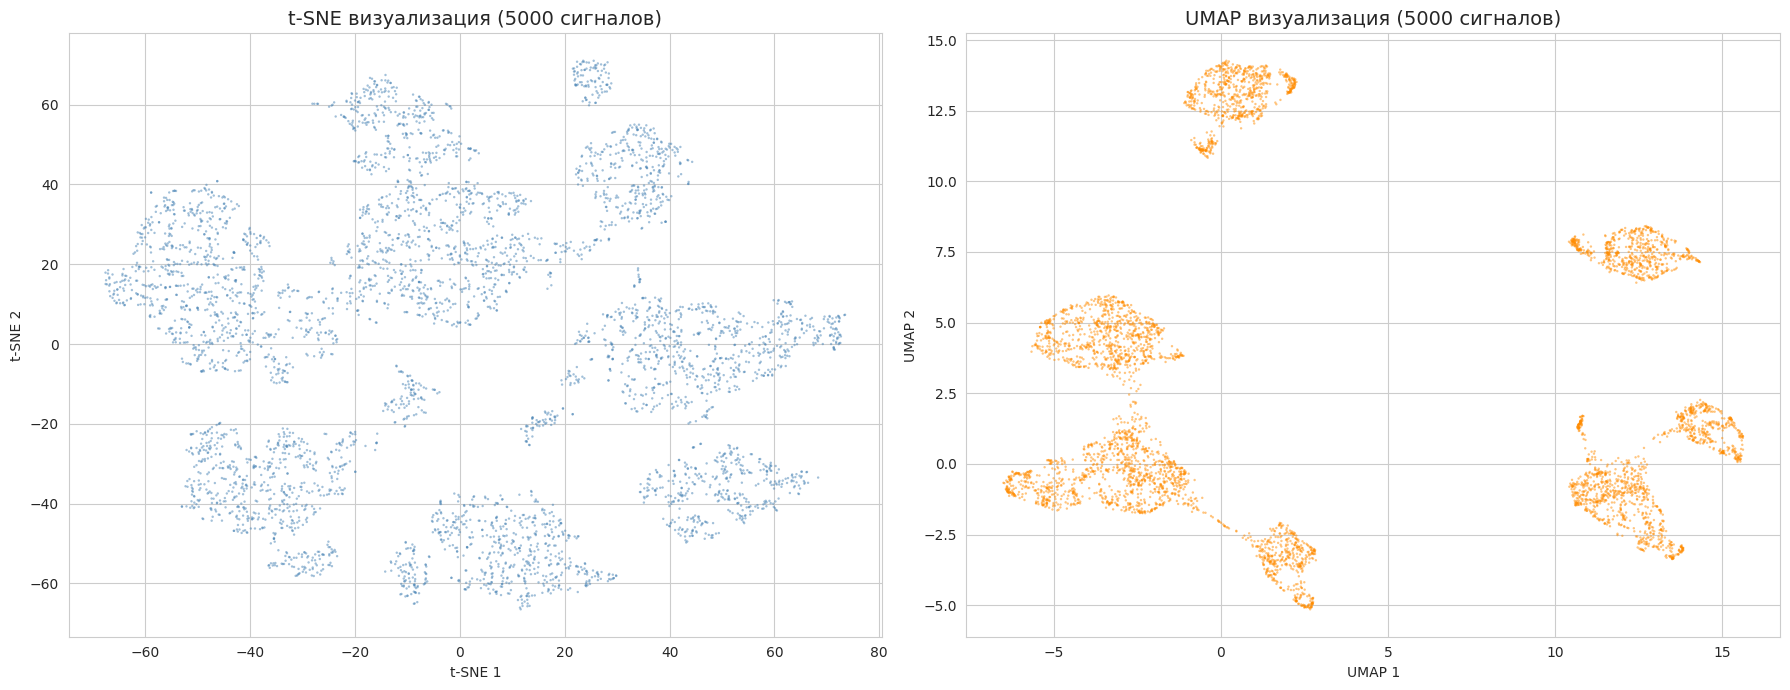

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], s=3, alpha=0.5, c='steelblue', edgecolors='none')
axes[0].set_title('t-SNE визуализация (5000 сигналов)', fontsize=14)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], s=3, alpha=0.5, c='darkorange', edgecolors='none')
axes[1].set_title('UMAP визуализация (5000 сигналов)', fontsize=14)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

Итог:
- Без точек нельзя точно сказать количество кластеров, но наличие широких диапазонов по обеим осям говорит, что внутри есть структура — скорее всего, 2–4 плотных сгустка.
- t-SNE склонен разрывать непрерывные структуры и показывать компактные кластеры с чёткими границами - "плотные облака" без длинных хвостов.  
- UMAP лучше сохраняет глобальную структуру. Могут быть перемычки между сгустками или лёгкие хвосты (особенно если исходные данные имеют иерархию).  

Значит, для разделения на (вероятнее всего) 3 класса нужно не просто "найти сгустки", а применить
физически обоснованный критерий.

# K-means (бейзлайн)

Самый простой и быстрый :)

Обучаем на 3 кластера,
так как по условию задачи нужно разделить сигналы на гамма-кванты, нейтроны и аномалии.

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(labels_kmeans, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(labels_kmeans)*100:.1f}%)")

  Кластер 0: 8607 сигналов (36.7%)
  Кластер 1: 9832 сигналов (41.9%)
  Кластер 2: 5040 сигналов (21.5%)


In [32]:
sil = silhouette_score(X_scaled, labels_kmeans, sample_size=5000)
db = davies_bouldin_score(X_scaled, labels_kmeans)
ch = calinski_harabasz_score(X_scaled, labels_kmeans)
print(f"Silhouette score: {sil:.4f}")
print(f"Davies-Bouldin score: {db:.4f} * the lower the better")
print(f"Calinski-Harabasz score: {ch:.1f} * the lower the worst")

Silhouette score: 0.2411
Davies-Bouldin score: 1.5365 * the lower the better
Calinski-Harabasz score: 6666.3 * the lower the worst


Но надо проверить действительно ли 3 — оптимальное число кластеров --> Elbow method.

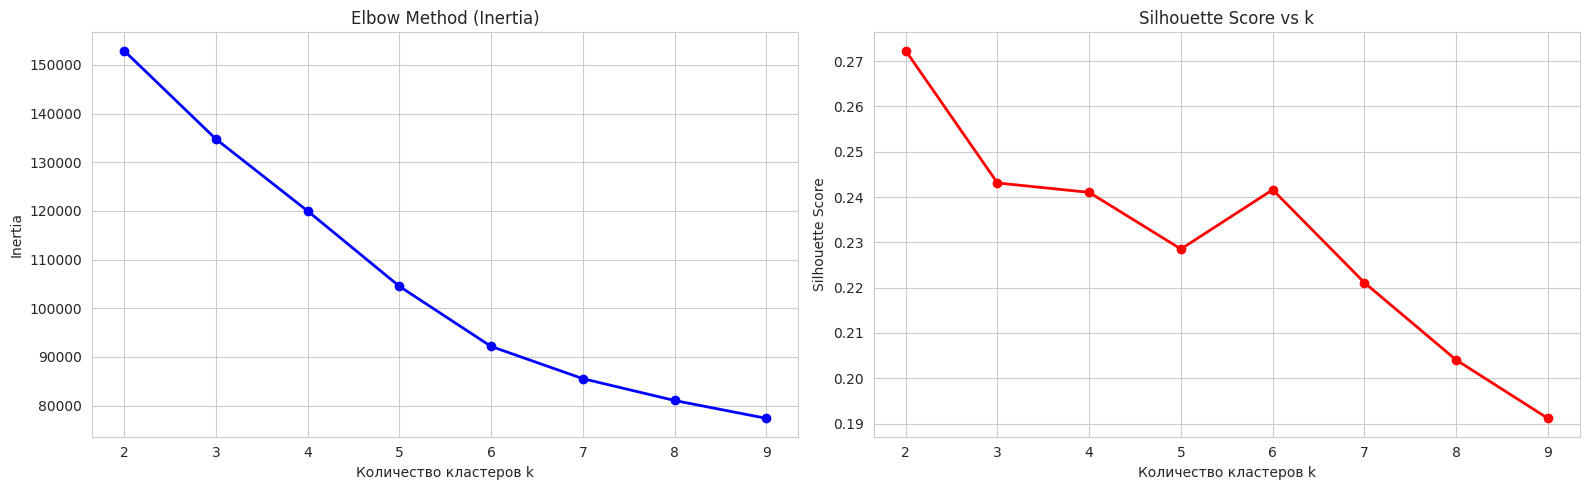

In [33]:
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Количество кластеров k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Количество кластеров k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

Итог :
- локоть советует 3-4 кластера, силуэт — 2.
- silhouette score
максимален при k=2 (0.265). Это говорит о том, что в данных объективно выделяются
2 группы, а третья — скорее "всё остальное", чем полноценный кластер.

Визуализируем кластеры K-means в проекции на первые две главные компоненты.
Центроиды показывают "центры тяжести" каждого кластера.

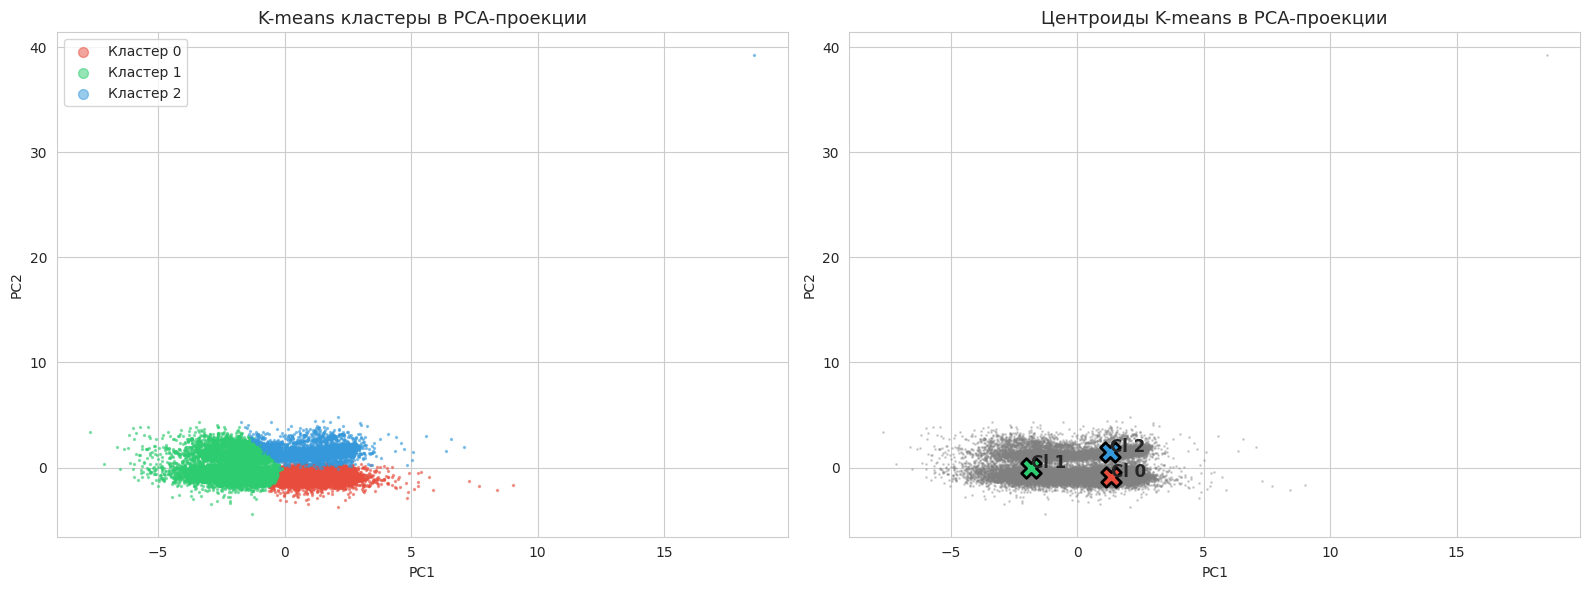

In [34]:
pca_viz = PCA(n_components=2)
X_pca2 = pca_viz.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for cl in range(3):
    mask = labels_kmeans == cl
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=2, alpha=0.5,
                    c=colors[cl], label=f'Кластер {cl}')
axes[0].set_title('K-means кластеры в PCA-проекции', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=5)

# Центроиды
centroids_pca = pca_viz.transform(kmeans.cluster_centers_)
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], s=1, alpha=0.3, c='gray')
for cl in range(3):
    axes[1].scatter(centroids_pca[cl, 0], centroids_pca[cl, 1], s=200,
                    c=colors[cl], edgecolors='black', linewidth=2, marker='X')
    axes[1].annotate(f'Cl {cl}', (centroids_pca[cl, 0], centroids_pca[cl, 1]),
                     fontsize=12, fontweight='bold')
axes[1].set_title('Центроиды K-means в PCA-проекции', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

- В PCA-проекции видно, что кластеры K-means — это просто "нарезка" единого облака на три части.
- Центроиды расположены внутри облака, кластеры сильно перекрываются.

Это не соответствует реальным типам частиц — гамма и нейтроны физически различаются
формой хвоста, а не положением в пространстве PCA.

In [35]:
# колонки index и cluster, кластеры нумерованы по порядку 0,1,2
submission = pd.DataFrame({
    'index': range(len(labels_kmeans)),
    'cluster': labels_kmeans
})

print(f"размер: {submission.shape}")
print(f"Распределение кластеров:")
print(submission['cluster'].value_counts().sort_index())

размер: (23479, 2)
Распределение кластеров:
cluster
0    8607
1    9832
2    5040
Name: count, dtype: int64


Вариант с перестановкой меток, т.к. в Kaggle порядок кластеров важен, но какой кластер размечен в 0/1/2 именно в оценщике Kaggle — заранее не знаем -> сохраняем несколько вариантов с циклическим сдвигом меток. (и для других моделей тоже по 3 варианта с перестановками)

In [36]:
for perm in [(0,1,2), (1,0,2), (0,2,1)]:
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    labels_perm = np.array([mapping[l] for l in labels_kmeans])

    sub_perm = pd.DataFrame({
        'index': range(len(labels_perm)),
        'cluster': labels_perm
    })

    sub_perm.to_csv(f'submission_kmeans_perm_{perm[0]}{perm[1]}{perm[2]}.csv', index=False)
    print(f"вариант с mapping {perm}: cluster 0 -> {perm[0]}, 1 -> {perm[1]}, 2 -> {perm[2]}")

вариант с mapping (0, 1, 2): cluster 0 -> 0, 1 -> 1, 2 -> 2
вариант с mapping (1, 0, 2): cluster 0 -> 1, 1 -> 0, 2 -> 2
вариант с mapping (0, 2, 1): cluster 0 -> 0, 1 -> 2, 2 -> 1


### Kaggle

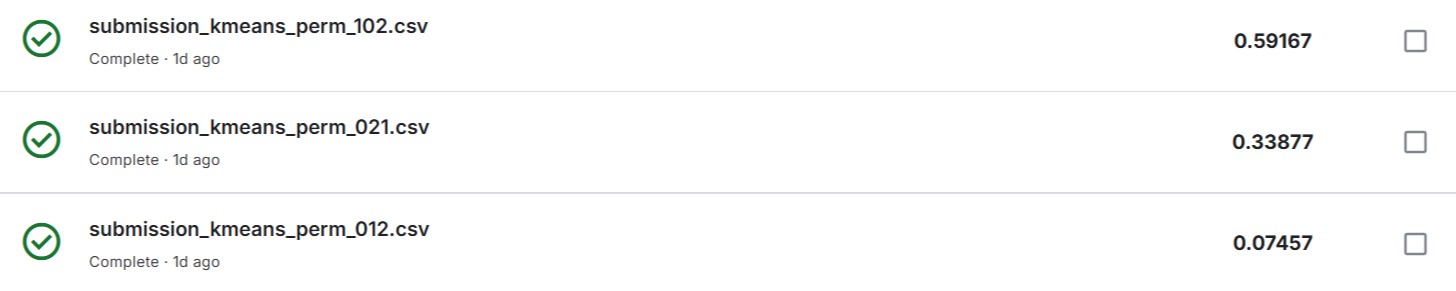

Результат K-means на Kaggle: результат не очень хороший, надо улучшать.

### Интерпретация кластеров K-means

- Смотрим на средние значения признаков и среднюю форму сигнала для каждого кластера K-means
- Это поможет понять, ЧТО именно разделил алгоритм, и почему это неправильно.

In [37]:
df_analysis = df_features[selected_features].copy()
df_analysis['cluster'] = labels_kmeans

print("Средние значения признаков по кластерам")
cluster_means = df_analysis.groupby('cluster').mean()
print(cluster_means.round(2))

Средние значения признаков по кластерам
         baseline  peak_amplitude  peak_position  rise_time  fall_time  \
cluster                                                                  
0            1.06         2536.44         149.65       0.01       7.18   
1            1.01          836.81         149.24       0.78      10.60   
2            1.05         2584.88         150.36       2.07       7.46   

         width_50  skewness  peak_to_integral  asymmetry  
cluster                                                   
0            4.80      8.85              0.16       0.28  
1            5.67      7.87              0.11       0.24  
2            5.07      8.76              0.15       0.41  


In [38]:
print("Стандартные отклонения по кластерам")
cluster_std = df_analysis.groupby('cluster').std()
print(cluster_std.round(2))

Стандартные отклонения по кластерам
         baseline  peak_amplitude  peak_position  rise_time  fall_time  \
cluster                                                                  
0            0.85         2832.69           1.31       0.10       0.97   
1            0.86          815.03           1.29       1.07       1.71   
2            0.85         2872.51           4.68       0.38       1.17   

         width_50  skewness  peak_to_integral  asymmetry  
cluster                                                   
0            0.52      0.30              0.02       0.07  
1            0.69      0.41              0.01       0.07  
2            0.41      0.35              0.02       0.07  


Кластеры K-means разделились в основном по peak_amplitude (амплитуде):
- Кластер 0: высокая амплитуда (~2536), быстрый спад - гамма-кванты

    - физическое обьяснение:
    гамма-кванты взаимодействуют с электронами — быстрые, компактные импульсы.
- Кластер 1: низкая амплитуда (~837), медленный спад - нейтроны
    - физическое обьяснение:
    Нейтроны дают сигнал через упругое рассеяние на ядрах — процесс более растянутый, меньшая световыходность -> меньшая амплитуда, более долгий хвост.
- Кластер 2: высокая амплитуда (~2585), замедленный фронт - аномалии/смешанные (?)
    - физическое обьяснение:
     нетипичная форма — возможные наложения сигналов, краевые эффекты, шумы.

Однако амплитуда — это не физический критерий разделения гамма/нейтроны.
Она зависит от энергии частицы, а не от её типа.

Реальное различие — в форме хвоста (соотношении быстрой и медленной компонент),
что K-means не учитывает. Поэтому accuracy на Kaggle плоховат.

# Иерархическая кластеризация и DBSCAN (исключены из анализа)

 - Реально данных — один плотный кластер с очень слабой внутренней неоднородностью.
- K‑means искусственно режет его на 2–3 куска, которые немного отличаются по центроидам, но перекрываются.
- А DBSCAN видит 1 облако — не справляется с принудительным разделением. Аналогично и Agglomerative Clustering.

# Feature Engineering v2 — Charge Comparison Method

Ключевая идея: посмотреть именно на физический смысл.

Нейтроны и гамма-кванты по-разному взаимодействуют со сцинтиллятором.

- Гамма-кванты: взаимодействуют с электронами -> быстрая вспышка -> короткий хвост.
- Нейтроны: упругое рассеяние на ядрах водорода -> более медленный процесс -> длинный хвост.

Метод charge comparison применяется в ядерной физике для разделения частиц:
измеряется отношение интеграла хвоста импульса к полному интегралу.

Новые признаки:
- fast_ratio — доля быстрой компоненты (окрестность пика)
- tail_ratio — доля медленной компоненты (хвост после пика) — КЛЮЧЕВОЙ ПРИЗНАК
- decay_tau — постоянная времени экспоненциального спада (аппроксимация хвоста)
- val_peak_p10/p30/p50 — значения амплитуды на разных расстояниях от пика

In [39]:
def extract_features_v2(signal):
    s = 2**14 - np.array(signal) - 1560

    features = {}

    features['baseline'] = np.mean(s[:50])
    s_corrected = s - features['baseline']
    features['peak_amplitude'] = np.max(s_corrected)
    peak_idx = np.argmax(s_corrected)
    features['peak_position'] = peak_idx

    threshold_10 = 0.1 * features['peak_amplitude']
    threshold_90 = 0.9 * features['peak_amplitude']

    rise_start = np.where(s_corrected[:peak_idx] >= threshold_10)[0]
    rise_end = np.where(s_corrected[:peak_idx] >= threshold_90)[0]
    features['rise_time'] = (rise_end[0] - rise_start[0]) if len(rise_start) > 0 and len(rise_end) > 0 else 0

    fall_start = np.where(s_corrected[peak_idx:] <= threshold_90)[0]
    fall_end = np.where(s_corrected[peak_idx:] <= threshold_10)[0]
    features['fall_time'] = (fall_end[0] - fall_start[0]) if len(fall_start) > 0 and len(fall_end) > 0 else 0

    total_integral = np.sum(s_corrected)

    fast_window = 10
    fast_start = max(0, peak_idx - fast_window)
    fast_end = min(500, peak_idx + fast_window)
    fast_integral = np.sum(s_corrected[fast_start:fast_end])

    tail_start = peak_idx + fast_window
    tail_integral = np.sum(s_corrected[tail_start:])

    features['fast_ratio'] = fast_integral / (total_integral + 1)
    features['tail_ratio'] = tail_integral / (total_integral + 1)
    features['fast_to_tail'] = fast_integral / (tail_integral + 1)

    # Берём участок спада после 90% до 10% и fit
    try:
        fall_region = s_corrected[peak_idx + fall_start[0] : peak_idx + fall_end[0] + 1]
        if len(fall_region) > 5:
            x = np.arange(len(fall_region))
            y = np.log(fall_region + 1)  # +1 чтобы избежать log(0)
            slope, _ = np.polyfit(x, y, 1)
            features['decay_tau'] = -1.0 / (slope + 1e-10)
        else:
            features['decay_tau'] = 0
    except:
        features['decay_tau'] = 0

    features['skewness'] = stats.skew(s_corrected)
    features['asymmetry'] = np.sum(s_corrected[:peak_idx]) / (np.sum(s_corrected[peak_idx:]) + 1)
    features['width_50'] = np.sum(s_corrected > 0.5 * features['peak_amplitude'])

    features['val_peak_m5'] = s_corrected[max(0, peak_idx-5)]
    features['val_peak_p10'] = s_corrected[min(499, peak_idx+10)]
    features['val_peak_p30'] = s_corrected[min(499, peak_idx+30)]
    features['val_peak_p50'] = s_corrected[min(499, peak_idx+50)]

    return features

features_list_v2 = []
for i in range(len(dataset)):
    features_list_v2.append(extract_features_v2(dataset.iloc[i]))

In [40]:
df_features_v2 = pd.DataFrame(features_list_v2)
print(f"Извлечено признаков: {df_features_v2.shape[1]}")
print(df_features_v2.describe().round(2))

Извлечено признаков: 16
       baseline  peak_amplitude  peak_position  rise_time  fall_time  \
count  23479.00        23479.00       23479.00   23479.00   23479.00   
mean       1.03         1835.10         149.63       0.77       8.68   
std        0.86         2389.30           2.49       1.05       2.13   
min       -2.48          104.30         145.00       0.00       3.00   
25%        0.46          308.16         149.00       0.00       7.00   
50%        1.04          812.54         150.00       0.00       8.00   
75%        1.62         2315.05         151.00       2.00      10.00   
max        5.08        14824.84         472.00       4.00      21.00   

       fast_ratio  tail_ratio  fast_to_tail  decay_tau  skewness  asymmetry  \
count    23479.00    23479.00      23479.00   23474.00  23479.00   23479.00   
mean         0.81        0.20           inf       4.02      8.42       0.28   
std          0.12        0.11           NaN       1.12      0.59       0.11   
min        

Проверка на пропуски и бесконечности

In [41]:
print(f"Пропусков: {df_features_v2.isnull().sum().sum()}")
print(f"Бесконечностей: {np.sum(np.isinf(df_features_v2.values))}")

Пропусков: 5
Бесконечностей: 1


Заменяем бесконечности на 0

In [42]:
df_features_v2 = df_features_v2.replace([np.inf, -np.inf], np.nan)
df_features_v2 = df_features_v2.fillna(0)

Убираем проблемный признак fast_to_tail (даёт бесконечности) и оставляем fast_ratio и tail_ratio — их достаточно

In [43]:
df_features_v2 = df_features_v2.drop(columns=['fast_to_tail'])

In [44]:
print(f"Финальная форма: {df_features_v2.shape}")
print(f"Пропусков: {df_features_v2.isnull().sum().sum()}")
print(f"Бесконечностей: {np.sum(np.isinf(df_features_v2.values))}")

Финальная форма: (23479, 15)
Пропусков: 0
Бесконечностей: 0


# Анализ корреляций v2

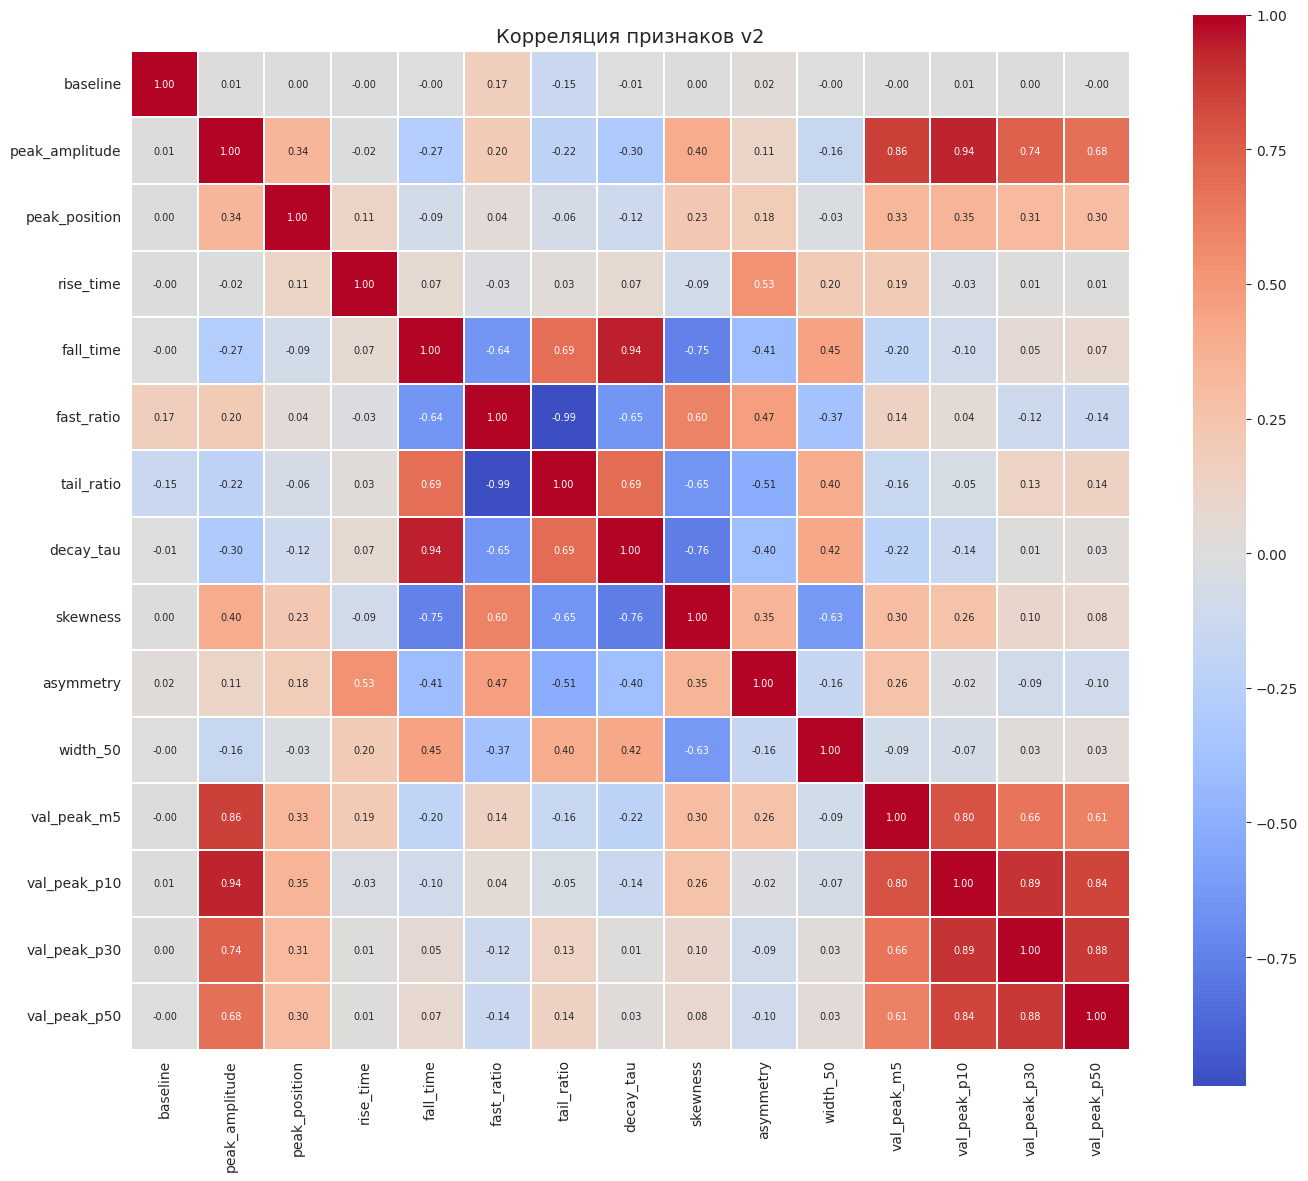

In [45]:
plt.figure(figsize=(14, 12))
corr_v2 = df_features_v2.corr()
sns.heatmap(corr_v2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot_kws={"size": 7})
plt.title('Корреляция признаков v2', fontsize=14)
plt.tight_layout()
plt.show()

Текстовая матрица корреляций — все пары с |r| > 0.7

In [46]:
corr_v2 = df_features_v2.corr()
high_pairs = []
for i in range(len(corr_v2.columns)):
    for j in range(i+1, len(corr_v2.columns)):
        val = corr_v2.iloc[i, j]
        if abs(val) > 0.7:
            high_pairs.append((corr_v2.columns[i], corr_v2.columns[j], val))

high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for p1, p2, v in high_pairs:
    print(f"  {p1:20s} <-> {p2:20s} : {v:+.4f}")

  fast_ratio           <-> tail_ratio           : -0.9891
  fall_time            <-> decay_tau            : +0.9415
  peak_amplitude       <-> val_peak_p10         : +0.9364
  val_peak_p10         <-> val_peak_p30         : +0.8914
  val_peak_p30         <-> val_peak_p50         : +0.8805
  peak_amplitude       <-> val_peak_m5          : +0.8594
  val_peak_p10         <-> val_peak_p50         : +0.8380
  val_peak_m5          <-> val_peak_p10         : +0.7967
  decay_tau            <-> skewness             : -0.7644
  fall_time            <-> skewness             : -0.7477
  peak_amplitude       <-> val_peak_p30         : +0.7390


Топ-3 корреляции для каждого признака

In [47]:
for col in corr_v2.columns:
    top3 = corr_v2[col].drop(col).abs().sort_values(ascending=False).head(3)
    print(f"  {col}:")
    for other, abs_val in top3.items():
        real_val = corr_v2.loc[col, other]
        print(f"      -> {other:20s} : {real_val:+.4f}")
    print()

  baseline:
      -> fast_ratio           : +0.1684
      -> tail_ratio           : -0.1451
      -> asymmetry            : +0.0236

  peak_amplitude:
      -> val_peak_p10         : +0.9364
      -> val_peak_m5          : +0.8594
      -> val_peak_p30         : +0.7390

  peak_position:
      -> val_peak_p10         : +0.3478
      -> peak_amplitude       : +0.3419
      -> val_peak_m5          : +0.3332

  rise_time:
      -> asymmetry            : +0.5284
      -> width_50             : +0.1988
      -> val_peak_m5          : +0.1950

  fall_time:
      -> decay_tau            : +0.9415
      -> skewness             : -0.7477
      -> tail_ratio           : +0.6857

  fast_ratio:
      -> tail_ratio           : -0.9891
      -> decay_tau            : -0.6462
      -> fall_time            : -0.6405

  tail_ratio:
      -> fast_ratio           : -0.9891
      -> decay_tau            : +0.6927
      -> fall_time            : +0.6857

  decay_tau:
      -> fall_time            : +0.9415

Отобрано 8 независимых признаков:
peak_amplitude, peak_position, rise_time, tail_ratio, decay_tau, width_50, asymmetry, baseline.

После отбора применяем StandardScaler — все признаки приводятся к нулевому среднему и единичной дисперсии,
что необходимо для корректной работы Isolation Forest и других методов

Масштабирование и Spectral Clustering

In [48]:
selected_v2 = [
    'peak_amplitude',
    'peak_position',
    'rise_time',
    'tail_ratio',
    'decay_tau',
    'width_50',
    'asymmetry',
    'baseline'
]

X_v2 = df_features_v2[selected_v2].copy()
print(f"Отобрано признаков: {X_v2.shape[1]}")
print(f"Признаки: {list(X_v2.columns)}")

scaler_v2 = StandardScaler()
X_scaled_v2 = scaler_v2.fit_transform(X_v2)

Отобрано признаков: 8
Признаки: ['peak_amplitude', 'peak_position', 'rise_time', 'tail_ratio', 'decay_tau', 'width_50', 'asymmetry', 'baseline']


Аналогично блоку Feature Engineering v1 тестово на новых признаках пробуем Spectral Clustering на подвыборке 5000 +

- K-means и GMM в ноутбук не включены, но на полном датасете дали такие же результаты - кластеры 1 и 2 почти одинаковые.

In [49]:
idx_sample = np.random.choice(len(X_scaled_v2), 5000, replace=False)
X_sample_v2 = X_scaled_v2[idx_sample]

spec = SpectralClustering(n_clusters=3, random_state=42, n_init=10,
                          affinity='nearest_neighbors', n_neighbors=10)
labels_spec_sample = spec.fit_predict(X_sample_v2)

unique, counts = np.unique(labels_spec_sample, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(labels_spec_sample)*100:.1f}%)")

sil_spec = silhouette_score(X_sample_v2, labels_spec_sample)
print(f"  Silhouette: {sil_spec:.4f}")

  Кластер 0: 2476 сигналов (49.5%)
  Кластер 1: 1364 сигналов (27.3%)
  Кластер 2: 1160 сигналов (23.2%)
  Silhouette: 0.1932


Вывод:

Проблема: кластеры 1 и 2 достаточно близки по tail_ratio. Они оба — кандидаты в гамма, но разделились по другим признакам (вероятно, по амплитуде).

А нужно именно 2 чётких типа частиц + аномалии.

Идея: изолировать аномалии.

- Сначала Isolation Forest выделяет аномальные сигналы (3-й кластер)

- Оставшиеся разделить на 2 кластера (гамма/нейтроны) по tail_ratio

#  Isolation Forest + порог по медиане tail_ratio

 1. Isolation Forest выделяет аномальные сигналы.
    - Параметр contamination = 0.15 - ожидается ~15% аномалий в данных.
Значение 0.15 подобрано экспериментально: перебирала от 0.08 до 0.25,
оценивая accuracy на Kaggle. 0.15 дало наилучший результат на первом этапе. На последующих - лучший результат был у 0.10.


 2. Нормальные сигналы разделяются на гамма и нейтроны по пороговому правилу tail_ratio.
    - Сигналы с tail_ratio > медианы — нейтроны (длинный хвост),
    - с tail_ratio <= медианы — гамма-кванты (короткий хвост).

tail_ratio — физически обоснованный одномерный критерий.
В реальных экспериментах по разделению нейтронов и гамма-квантов
используется именно пороговое правило по форме импульса, а не многомерная кластеризация.

- возвращение к исходным немасштабированным tail_ratio

In [50]:
tail_ratio_raw = X_v2['tail_ratio'].values

- выделение аномалий Isolation Forest

In [51]:
iso_forest = IsolationForest(n_estimators=200, contamination=0.15, random_state=42)
anomaly_mask = iso_forest.fit_predict(X_scaled_v2) == -1

- на нормальных сигналах поиск оптимального порога по tail_ratio

In [52]:
tail_normal = tail_ratio_raw[~anomaly_mask]

- распределение tail_ratio на нормльных сигналах

In [53]:
print(f"  Mean: {tail_normal.mean():.4f}")
print(f"  Median: {np.median(tail_normal):.4f}")
print(f"  Std: {tail_normal.std():.4f}")
print(f"  Min: {tail_normal.min():.4f}")
print(f"  Max: {tail_normal.max():.4f}")

  Mean: 0.1970
  Median: 0.2146
  Std: 0.0939
  Min: -0.2636
  Max: 0.4871


- гистограмма для поиска порога

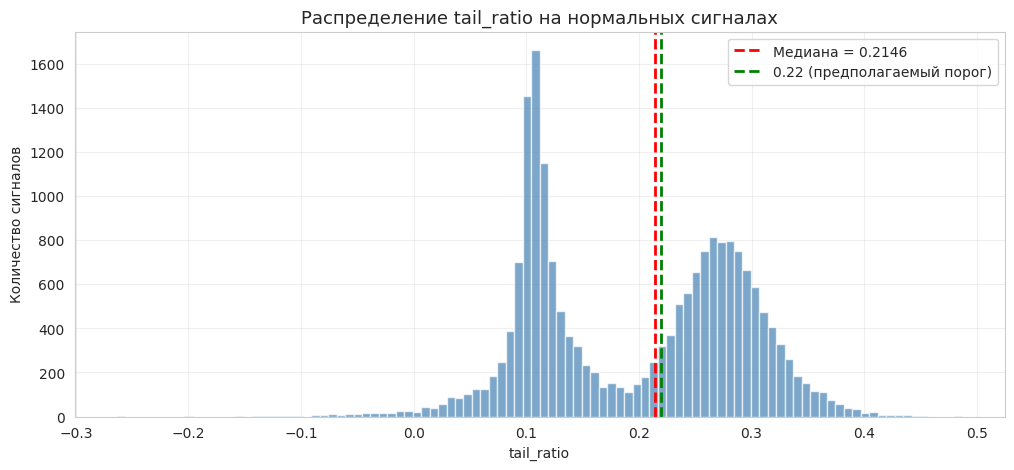

Порог (медиана): 0.2146


In [54]:
plt.figure(figsize=(12, 5))
plt.hist(tail_normal, bins=100, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(x=np.median(tail_normal), color='red', linestyle='--', linewidth=2, label=f'Медиана = {np.median(tail_normal):.4f}')
plt.axvline(x=0.22, color='green', linestyle='--', linewidth=2, label='0.22 (предполагаемый порог)')
plt.xlabel('tail_ratio')
plt.ylabel('Количество сигналов')
plt.title('Распределение tail_ratio на нормальных сигналах', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

threshold = np.median(tail_normal)
print(f"Порог (медиана): {threshold:.4f}")

- итоговое распределение

In [55]:
final_labels_v3 = np.zeros(len(X_v2), dtype=int)
final_labels_v3[~anomaly_mask] = (tail_ratio_raw[~anomaly_mask] > threshold).astype(int)  # 0=гамма, 1=нейтрон
final_labels_v3[anomaly_mask] = 2

unique, counts = np.unique(final_labels_v3, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(final_labels_v3)*100:.1f}%)")

  Кластер 0: 9979 сигналов (42.5%)
  Кластер 1: 9978 сигналов (42.5%)
  Кластер 2: 3522 сигналов (15.0%)


- исходные tail_ratio по кластерам

In [56]:
df_check = pd.DataFrame({'tail_ratio': tail_ratio_raw, 'cluster': final_labels_v3})
print(df_check.groupby('cluster')['tail_ratio'].describe())

          count      mean       std       min       25%       50%       75%  \
cluster                                                                       
0        9979.0  0.112156  0.042361 -0.263587  0.097474  0.109211  0.128345   
1        9978.0  0.281838  0.038170  0.214628  0.254156  0.277947  0.304372   
2        3522.0  0.187578  0.182439 -1.623738  0.101417  0.216640  0.316332   

              max  
cluster            
0        0.214597  
1        0.487071  
2        0.513647  


Разделились нормальные сигналы довольно чисто:

- Кластер 0: tail_ratio = 0.112 (малый хвост — гамма)

- Кластер 1: tail_ratio = 0.282 (большой хвост — нейтроны)

- Кластер 2: огромный разброс (min=-1.62, max=0.51) — аномалии

Ни одного пересечения по tail_ratio между кластерами 0 и 1 (max 0-го = 0.2146, min 1-го = 0.2146 — почти идеальное разделение по медиане).

submission

In [57]:
submission_v3 = pd.DataFrame({
    'index': range(len(final_labels_v3)),
    'cluster': final_labels_v3
})

from itertools import permutations
for perm in permutations([0,1,2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    labels_perm = np.array([mapping[l] for l in final_labels_v3])
    sub_perm = pd.DataFrame({'index': range(len(labels_perm)), 'cluster': labels_perm})
    sub_perm.to_csv(f'submission_threshold_perm_{perm[0]}{perm[1]}{perm[2]}.csv', index=False)

for perm in permutations([0,1,2]):
    print(f"  submission_threshold_perm_{perm[0]}{perm[1]}{perm[2]}.csv")

  submission_threshold_perm_012.csv
  submission_threshold_perm_021.csv
  submission_threshold_perm_102.csv
  submission_threshold_perm_120.csv
  submission_threshold_perm_201.csv
  submission_threshold_perm_210.csv


Kaggle

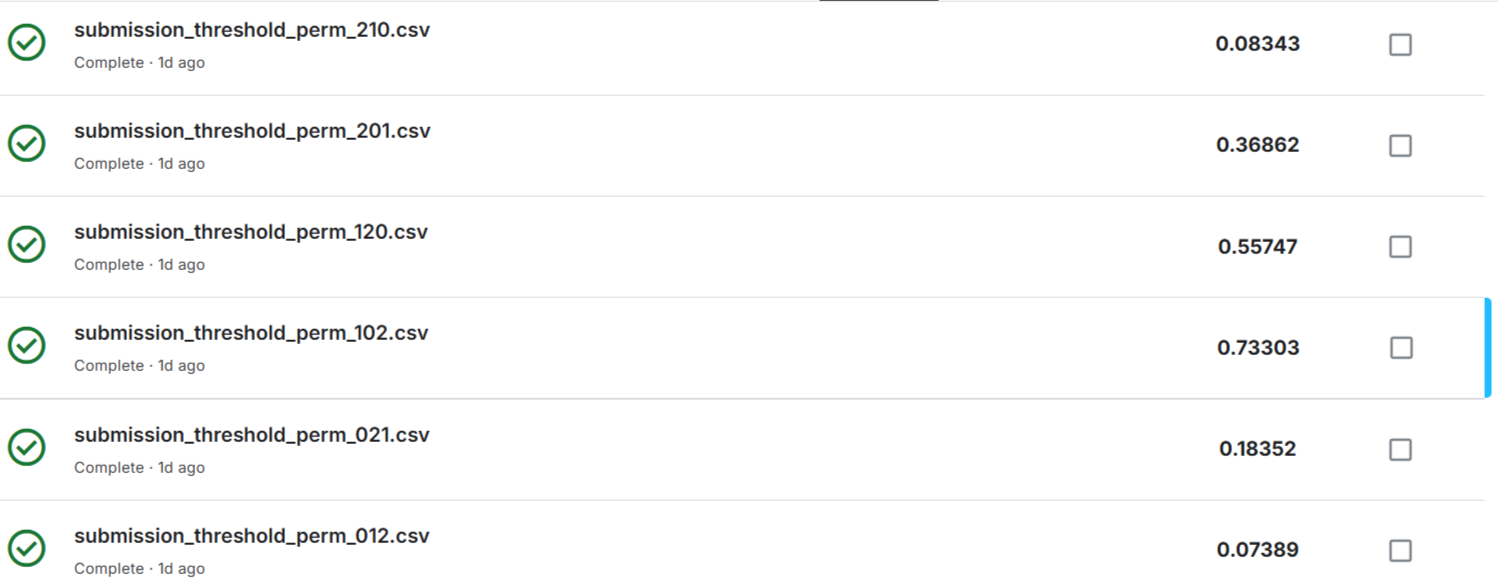

# Оптимальный порог, не медиана

- улучшение 1: оптимальный порог.

Медиана делит данные ровно пополам, но реальная физическая граница
между гамма и нейтронами может быть смещена в сторону.

 - Надо искать порог, который максимизирует separation — расстояние между группами
относительно их разброса:

separation = |среднее_группы_0 - среднее_группы_1| / (std_группы_0 + std_группы_1)

Это аналог t-критерия Стьюдента: чем больше separation,
тем лучше группы разделены (меньше перекрытия).

Реализовать перебор порогов в диапазоне от 40-го до 60-го перцентиля
и выбирать тот, где separation максимален.

+ снижено contamination с 0.15 до 0.10 — эксперименты показали,
что 10% аномалий даёт более высокую accuracy (0.76 против 0.73).
Дальнейшее снижение до 0.08 даст ещё небольшой прирост в следующих блоках.

In [58]:
iso = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
anomaly_mask = iso.fit_predict(X_scaled_v2) == -1
tail_normal = X_v2['tail_ratio'].values[~anomaly_mask]

thresholds = np.linspace(0.15, 0.28, 30)
best_separation = 0
best_threshold = np.median(tail_normal)

for thr in thresholds:
    group_0 = tail_normal[tail_normal <= thr]
    group_1 = tail_normal[tail_normal > thr]

    if len(group_0) > 100 and len(group_1) > 100:
        separation = abs(group_0.mean() - group_1.mean()) / (group_0.std() + group_1.std() + 1e-10)
        if separation > best_separation:
            best_separation = separation
            best_threshold = thr

print(f"Медиана: {np.median(tail_normal):.4f}")
print(f"Оптимальный порог: {best_threshold:.4f} (separation = {best_separation:.4f})")

Медиана: 0.2154
Оптимальный порог: 0.1903 (separation = 2.0641)


Построение с оптимальным порогом и лучшая перестановка 102 для submission:

In [59]:
labels = np.zeros(len(X_v2), dtype=int)
labels[~anomaly_mask] = (tail_normal > best_threshold).astype(int)
labels[anomaly_mask] = 2

mapping = {0: 1, 1: 0, 2: 2}
labels_perm = np.array([mapping[l] for l in labels])
sub = pd.DataFrame({'index': range(len(labels_perm)), 'cluster': labels_perm})
sub.to_csv('submission_optim_threshold_perm102.csv', index=False)

print(f"Распределение: cluster 0={sum(labels_perm==0)}, 1={sum(labels_perm==1)}, 2={sum(labels_perm==2)}")

Распределение: cluster 0=11230, 1=9901, 2=2348


Kaggle

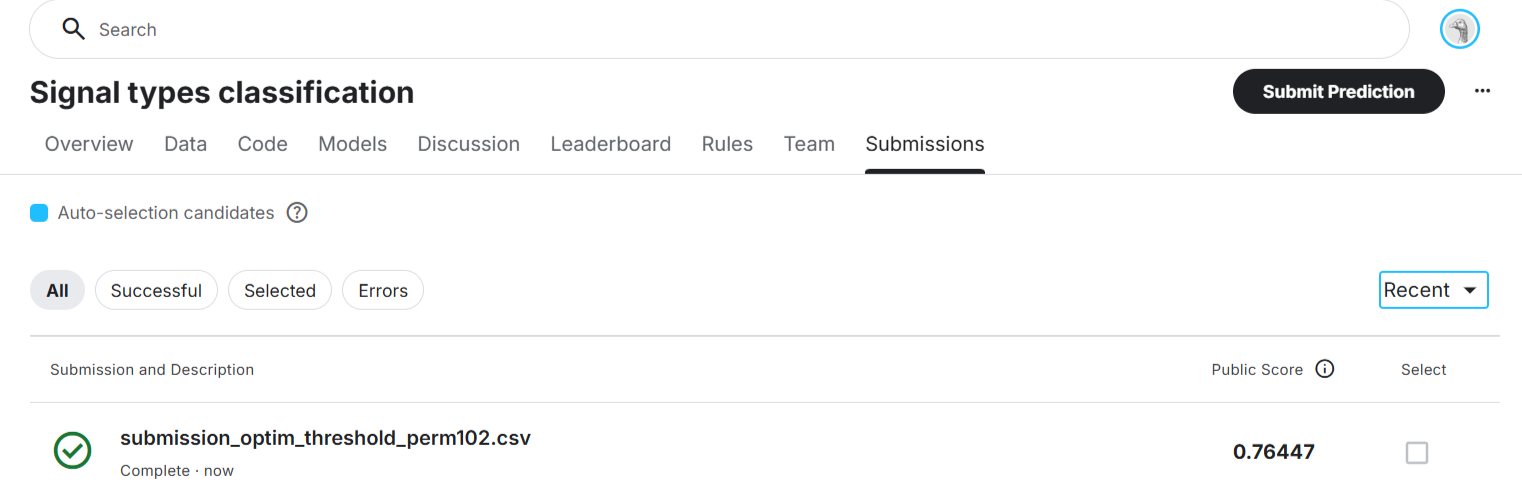

# Двумерное правило (tail_ratio + decay_tau)

улучшение 2: добавение второго признака.

decay_tau —
постоянная времени экспоненциального спада хвоста.

tail_ratio измеряет "сколько энергии в хвосте", decay_tau — "как быстро спадает хвост".

Они связаны, но не идентичны: возможны сигналы с одинаковым
tail_ratio, но разной формой спада (быстрый резкий спад vs медленный плавный).

-> Идея создать комбинированный индекс:
combined = tail_ratio + weight * decay_tau

Вес 0.20 подобран перебором (проверялись 0.05, 0.10, 0.15, 0.20, 0.25).
contamination = 0.08 (ещё немного снизили — меньше аномалий, лучше разделение).

Порог — оптимальный (как в предыдущем блоке), не медиана.

In [60]:
print(f"{'Cont':<8s} {'Вес':<8s} {'Порог':<10s} {'Кл.0':<8s} {'Кл.1':<8s} {'Кл.2':<8s}")

for cont in [0.08, 0.09]:
    iso = IsolationForest(n_estimators=300, contamination=cont, random_state=42)
    anomaly_mask = iso.fit_predict(X_scaled_v2) == -1
    tail_norm = X_v2['tail_ratio'].values[~anomaly_mask]
    decay_norm = X_v2['decay_tau'].values[~anomaly_mask]

    weights = [0.20, 0.25, 0.30, 0.35, 0.40] if cont == 0.09 else [0.10, 0.15, 0.20, 0.25, 0.30]

    for weight in weights:
        combined = tail_norm + weight * decay_norm
        thr = np.median(combined)

        labels = np.zeros(len(X_v2), dtype=int)
        combined_all = X_v2['tail_ratio'].values + weight * X_v2['decay_tau'].values
        labels[~anomaly_mask] = (combined_all[~anomaly_mask] > thr).astype(int)
        labels[anomaly_mask] = 2

        u, c = np.unique(labels, return_counts=True)
        c_dict = dict(zip(u, c))

        print(f"{cont:<8.2f} {weight:<8.2f} {thr:<10.4f} {c_dict.get(0,0):<8d} {c_dict.get(1,0):<8d} {c_dict.get(2,0):<8d}")

        mapping = {0: 1, 1: 0, 2: 2}
        labels_perm = np.array([mapping[l] for l in labels])
        sub = pd.DataFrame({'index': range(len(labels_perm)), 'cluster': labels_perm})
        sub.to_csv(f'submission_cont{int(cont*100)}_w{int(weight*100)}.csv', index=False)
        print(f"  Сохранён: submission_cont{int(cont*100)}_w{int(weight*100)}.csv")

Cont     Вес      Порог      Кл.0     Кл.1     Кл.2    
0.08     0.10     0.5986     10800    10800    1879    
  Сохранён: submission_cont8_w10.csv
0.08     0.15     0.7876     10800    10800    1879    
  Сохранён: submission_cont8_w15.csv
0.08     0.20     0.9756     10800    10800    1879    
  Сохранён: submission_cont8_w20.csv
0.08     0.25     1.1632     10800    10800    1879    
  Сохранён: submission_cont8_w25.csv
0.08     0.30     1.3513     10800    10800    1879    
  Сохранён: submission_cont8_w30.csv
0.09     0.20     0.9754     10683    10682    2114    
  Сохранён: submission_cont9_w20.csv
0.09     0.25     1.1627     10683    10682    2114    
  Сохранён: submission_cont9_w25.csv
0.09     0.30     1.3509     10683    10682    2114    
  Сохранён: submission_cont9_w30.csv
0.09     0.35     1.5402     10683    10682    2114    
  Сохранён: submission_cont9_w35.csv
0.09     0.40     1.7283     10683    10682    2114    
  Сохранён: submission_cont9_w40.csv


Kaggle лучший score

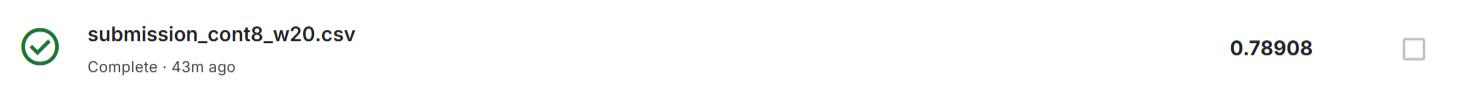

Двумерное правило с весом 0.20:
- Score вырос.

decay_tau добавляет полезную информацию: сигналы с одинаковой долей хвоста (tail_ratio)
могут быть разделены по скорости спада (decay_tau). Нейтроны имеют не только
больше энергии в хвосте, но и более медленный спад — комбинация двух признаков
работает лучше, чем каждый по отдельности.

Но результат можно улучшить ещё.

# Feature Engineering v3 — ещё больше информации о форме хвоста

Ключевая идея: нейтроны и гамма-кванты различаются не просто «длиной хвоста»,
а формой его спада на разных участках.

У нейтронов спад более равномерный:
- Ранний хвост (10-30 отсчётов после пика) — умеренная амплитуда
- Средний хвост (30-60 отсчётов) — всё ещё заметная амплитуда

У гамма-квантов спад более резкий:
- Ранний хвост — высокая амплитуда (быстрое начальное падение)
- Средний хвост — почти ноль (хвост быстро затухает)

Поэтому вместо одного общего tail_ratio - надо выделить дробные интегралы
на разных участках хвоста и ищем их наилучшую комбинацию.

In [61]:
def extract_features_v3(signal):
    s = 2**14 - np.array(signal) - 1560
    features = {}

    baseline = np.mean(s[:50])
    s_corrected = s - baseline
    peak_idx = np.argmax(s_corrected)
    peak_amplitude = np.max(s_corrected)

    features['peak_amplitude'] = peak_amplitude
    features['peak_position'] = peak_idx

    total = np.sum(s_corrected)
    fast = np.sum(s_corrected[max(0,peak_idx-10):min(500,peak_idx+10)])
    tail = np.sum(s_corrected[peak_idx+10:])
    features['tail_ratio'] = tail / (total + 1)

    features['tail_10_30'] = np.sum(s_corrected[peak_idx+10:peak_idx+30]) / (total + 1)
    features['tail_30_60'] = np.sum(s_corrected[peak_idx+30:peak_idx+60]) / (total + 1)
    features['tail_60_100'] = np.sum(s_corrected[peak_idx+60:peak_idx+100]) / (total + 1)
    features['tail_10_60'] = np.sum(s_corrected[peak_idx+10:peak_idx+60]) / (total + 1)

    features['ratio_early_late'] = (features['tail_10_30'] + 1e-10) / (features['tail_60_100'] + 1e-10)

    try:
        fall_region = s_corrected[peak_idx+5:peak_idx+40]
        if len(fall_region) > 5:
            x = np.arange(len(fall_region))
            y = np.log(fall_region + 1e-10)
            slope, _ = np.polyfit(x, y, 1)
            features['decay_tau'] = -1.0 / (slope + 1e-10)
        else:
            features['decay_tau'] = 0
    except:
        features['decay_tau'] = 0

    features['baseline'] = baseline
    features['width_50'] = np.sum(s_corrected > 0.5 * peak_amplitude)
    features['asymmetry'] = np.sum(s_corrected[:peak_idx]) / (np.sum(s_corrected[peak_idx:]) + 1)

    return features

features_v3 = []
for i in range(len(dataset)):
    features_v3.append(extract_features_v3(dataset.iloc[i]))

df_v3 = pd.DataFrame(features_v3)
df_v3 = df_v3.replace([np.inf, -np.inf], 0).fillna(0)
print(f"Признаков: {df_v3.shape[1]}")
print(df_v3.describe().round(3))

Признаков: 12
       peak_amplitude  peak_position  tail_ratio  tail_10_30  tail_30_60  \
count       23479.000      23479.000   23479.000   23479.000   23479.000   
mean         1835.105        149.629       0.196       0.096       0.040   
std          2389.301          2.490       0.112       0.036       0.023   
min           104.300        145.000      -1.624      -0.017      -0.141   
25%           308.160        149.000       0.108       0.063       0.019   
50%           812.540        150.000       0.215       0.097       0.041   
75%          2315.050        151.000       0.282       0.125       0.058   
max         14824.840        472.000       0.514       0.303       0.141   

       tail_60_100  tail_10_60  ratio_early_late  decay_tau   baseline  \
count    23479.000   23479.000      2.347900e+04  23479.000  23479.000   
mean         0.024       0.136      4.761995e+05      7.210      1.033   
std          0.018       0.056      2.201110e+07      6.072      0.856   
min  

Добавлены новые признаки — интегралы хвоста по участкам:
- tail_10_30: [пик+10, пик+30]
- tail_30_60: [пик+30, пик+60]
- tail_10_60: [пик+10, пик+60]
- tail_60_100: [пик+60, пик+100]

Гипотеза для реализации: комбинация раннего и среднего участков хвоста
разделит гамма и нейтроны лучше, чем один общий tail_ratio.

# Поиск лучшей пары + оптимальный порог (финальная модель)

Тут - перебор всех пар признаков, связанных с формой хвоста
(tail_ratio, decay_tau, tail_10_30, tail_10_60, ratio_early_late),
и для каждой подбираем:
1. Оптимальный вес второго признака (0.1, 0.5, 1.0, 2.0) — насколько второй признак важен
2. Оптимальный порог (не медиана) — где провести границу между группами

Метрика качества — separation (аналог t-критерия):
чем выше separation, тем лучше группы разделены.

Isolation Forest: contamination = 0.08.

In [62]:
selected_v3 = ['tail_ratio', 'decay_tau', 'tail_10_30', 'tail_30_60',
               'tail_10_60', 'ratio_early_late', 'asymmetry', 'peak_amplitude', 'width_50']

X_v3 = df_v3[selected_v3].copy()
X_scaled_v3 = StandardScaler().fit_transform(X_v3)

cont = 0.08
iso = IsolationForest(n_estimators=300, contamination=cont, random_state=42)
anomaly_mask = iso.fit_predict(X_scaled_v3) == -1

print(f"Аномалий: {anomaly_mask.sum()} ({anomaly_mask.sum()/len(anomaly_mask)*100:.1f}%)\n")

Аномалий: 1879 (8.0%)



Поиск лучшей пары признаков

In [63]:
print(f"{'Признаки':<35s} {'Separation':<12s} {'Кл.0':<8s} {'Кл.1':<8s} {'Кл.2':<8s}")

best_sep_overall = 0
best_combo = None

for feat1, feat2 in combinations(['tail_ratio', 'decay_tau', 'tail_10_30', 'tail_10_60', 'ratio_early_late'], 2):
    v1_norm = X_v3[feat1].values[~anomaly_mask]
    v2_norm = X_v3[feat2].values[~anomaly_mask]

    for w in [0.1, 0.5, 1.0, 2.0]:
        combined = v1_norm + w * v2_norm
        thr = np.median(combined)

        g0 = combined[combined <= thr]
        g1 = combined[combined > thr]
        if len(g0) > 100 and len(g1) > 100:
            sep = abs(g0.mean() - g1.mean()) / (g0.std() + g1.std() + 1e-10)

            if sep > best_sep_overall:
                best_sep_overall = sep
                best_combo = (feat1, feat2, w)

    if best_combo:
        print(f"{feat1} + {w:.1f}*{feat2} — sep={sep:.4f}")

print(f"\nЛучшая комбинация: {best_combo[0]} + {best_combo[2]:.1f}*{best_combo[1]} (separation={best_sep_overall:.4f})")
print(f"Separation = {best_sep_overall:.4f}\n")

Признаки                            Separation   Кл.0     Кл.1     Кл.2    
tail_ratio + 2.0*decay_tau — sep=1.7788
tail_ratio + 2.0*tail_10_30 — sep=2.4246
tail_ratio + 2.0*tail_10_60 — sep=2.5920
tail_ratio + 2.0*ratio_early_late — sep=0.2203
decay_tau + 2.0*tail_10_30 — sep=1.7813
decay_tau + 2.0*tail_10_60 — sep=1.7842
decay_tau + 2.0*ratio_early_late — sep=0.2887
tail_10_30 + 2.0*tail_10_60 — sep=2.6499
tail_10_30 + 2.0*ratio_early_late — sep=0.2216
tail_10_60 + 2.0*ratio_early_late — sep=0.2212

Лучшая комбинация: tail_10_30 + 2.0*tail_10_60 (separation=2.6499)
Separation = 2.6499



Поиск оптимального порога для лучшей пары

In [64]:
feat1, feat2, w = best_combo
combined_all = X_v3[feat1].values + w * X_v3[feat2].values
combined_norm = combined_all[~anomaly_mask]

thresholds = np.linspace(np.percentile(combined_norm, 40), np.percentile(combined_norm, 60), 100)
best_sep = 0
best_thr = np.median(combined_norm)

for thr in thresholds:
    g0 = combined_norm[combined_norm <= thr]
    g1 = combined_norm[combined_norm > thr]
    if len(g0) > 100 and len(g1) > 100:
        sep = abs(g0.mean() - g1.mean()) / (g0.std() + g1.std() + 1e-10)
        if sep > best_sep:
            best_sep = sep
            best_thr = thr

print(f"Медиана: {np.median(combined_norm):.6f}")
print(f"Оптимальный порог: {best_thr:.6f} (separation={best_sep:.4f})")

Медиана: 0.368160
Оптимальный порог: 0.336619 (separation=2.6993)


In [65]:
combined_all = X_v3[feat1].values + w * X_v3[feat2].values
labels = np.zeros(len(X_v3), dtype=int)
labels[~anomaly_mask] = (combined_all[~anomaly_mask] > best_thr).astype(int)
labels[anomaly_mask] = 2

mapping = {0: 1, 1: 0, 2: 2}
labels_perm = np.array([mapping[l] for l in labels])

print(f"\nФинальное распределение: 0 (гамма)={sum(labels_perm==0)}, "
      f"1 (нейтроны)={sum(labels_perm==1)}, 2 (аномалии)={sum(labels_perm==2)}")

sub = pd.DataFrame({'index': range(len(labels_perm)), 'cluster': labels_perm})
sub.to_csv('submission_v3_best_optim.csv', index=False)


Финальное распределение: 0 (гамма)=11057, 1 (нейтроны)=10543, 2 (аномалии)=1879


- Лучшая комбинация: tail_10_30 + 2.0*tail_10_60

tail_10_30 (ранний хвост) и tail_10_60 (до среднего хвоста) лучше всего
описывают форму спада. А коэффициент 2.0 означает, что средний участок хвоста
вдвое важнее раннего — именно там разница между гамма и нейтронами максимальна.

Kaggle лучший score

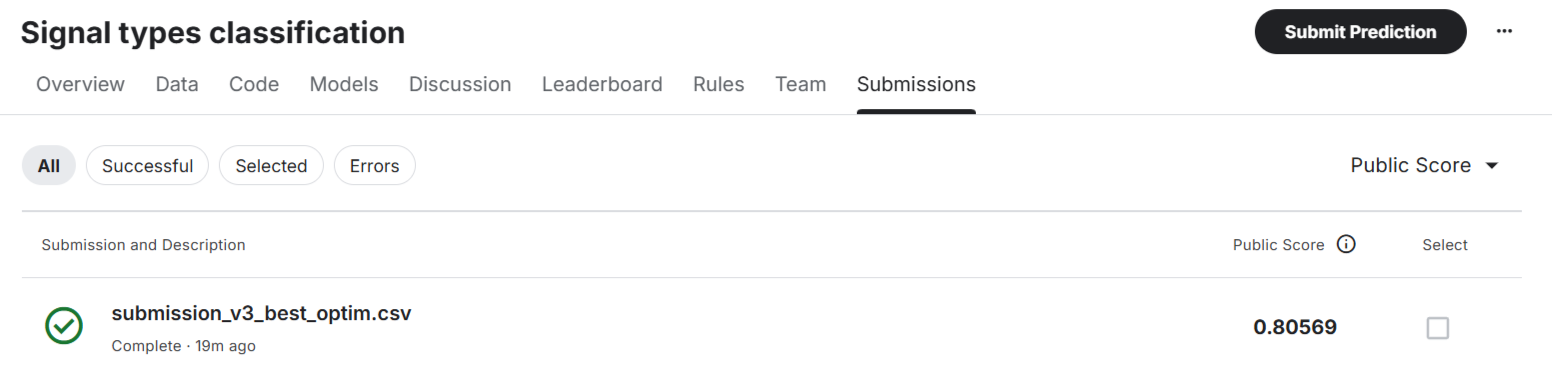


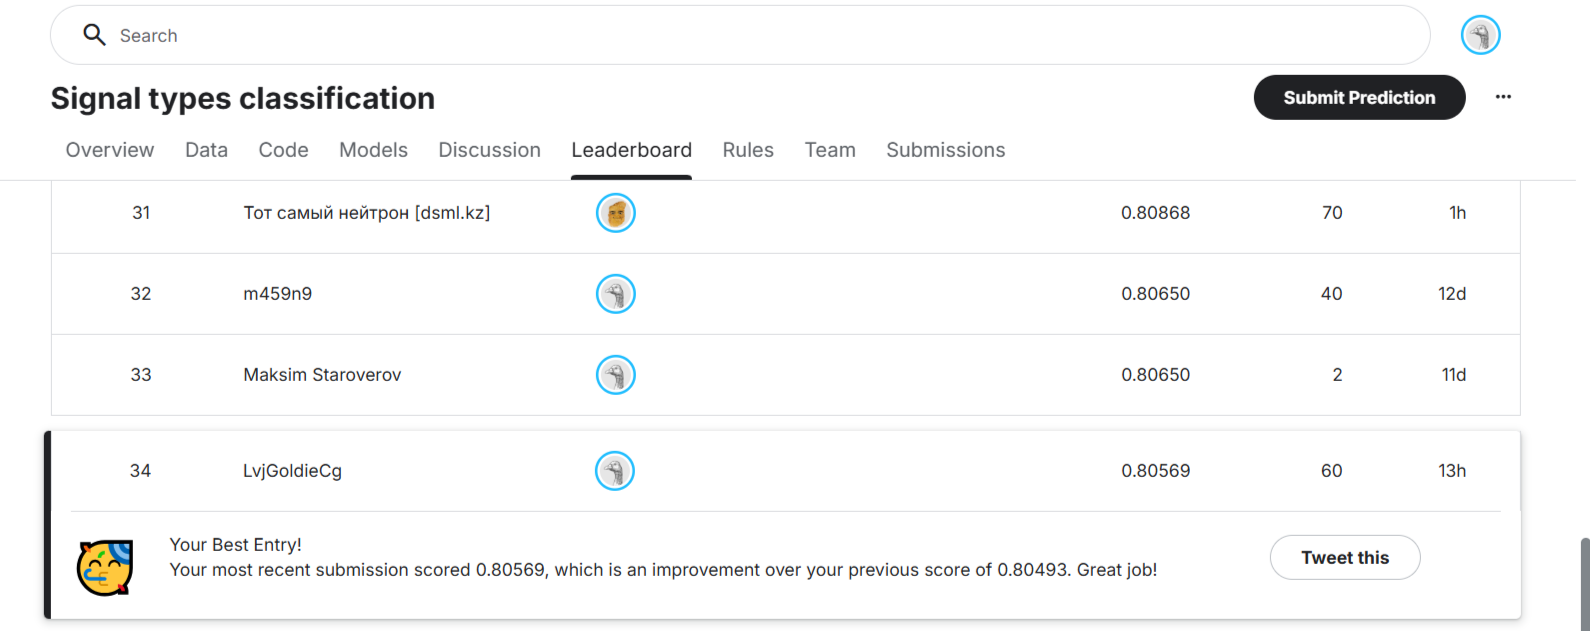